# Topic Modeling of Entrepreneurship Studies: LDA vs. BERTopic on an OpenAlex Corpus

## Environment and reproducibility

In [1]:
from pathlib import Path
import ast
import json
import os
import pickle
import re
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown
import pyarrow.parquet as pq
import pyarrow.dataset as ds

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

# ---- portable path setup ----
# SCRIPTS_DIR: the folder with the pipeline modules (p01..p14, analysis_config.py) — normally the folder of this notebook;
# ROOT: the data folder "entrepreneurship_corpus" (raw snapshot + derived/ artifacts) — next to the notebook folder, inside it,
# or in ~/Downloads; both can be overridden with the environment variables PIPELINE_SCRIPTS_DIR and ENTREPRENEURSHIP_ROOT.
def _first_existing(candidates, marker, what):
    for candidate in candidates:
        if candidate and (Path(candidate) / marker).exists():
            return Path(candidate).resolve()
    raise FileNotFoundError(f"{what} not found; looked in: " + ", ".join(str(c) for c in candidates if c))

SCRIPTS_DIR = _first_existing([os.environ.get("PIPELINE_SCRIPTS_DIR"), Path.cwd(), Path.cwd() / "pipeline"],
                              "analysis_config.py", "pipeline modules (analysis_config.py, p01..p14)")
ROOT = _first_existing([os.environ.get("ENTREPRENEURSHIP_ROOT"), SCRIPTS_DIR.parent / "entrepreneurship_corpus",
                        SCRIPTS_DIR / "entrepreneurship_corpus", Path.home() / "Downloads" / "entrepreneurship_corpus"],
                       "derived", "data folder entrepreneurship_corpus (with derived/)")
print("pipeline modules:", SCRIPTS_DIR, "\ndata root:       ", ROOT)

DERIVED_DIR = ROOT / "derived"
RUN_HEAVY = False          # True runs the pipeline stages with the frozen configuration and the existing manual-audit artifacts (hours); False reads the stored outputs only
PIPELINE_PYTHON = Path(os.environ.get("PIPELINE_PYTHON", SCRIPTS_DIR / ".venv" / "bin" / "python"))   # the frozen pipeline environment (requirements_lock.txt); used only if RUN_HEAVY

sys.path.insert(0, str(SCRIPTS_DIR))
import analysis_config as config     # frozen research design: every fixed parameter below is read from here


def load_json(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def read_csv(path, **kwargs):
    return pd.read_csv(path, **kwargs)


def show_source(module_file, function_names):
    # print the source of selected functions from a pipeline module without importing it
    tree = ast.parse(Path(module_file).read_text(encoding="utf-8"))
    text = Path(module_file).read_text(encoding="utf-8")
    for node in tree.body:
        if isinstance(node, ast.FunctionDef) and node.name in function_names:
            print(f"# ---- {Path(module_file).name}: {node.name} ----")
            print(ast.get_source_segment(text, node))
            print()


def show_excerpt(module_file, start_marker, end_marker):
    # print a top-level block of a pipeline module between two comment markers (for logic not wrapped in a function)
    lines = Path(module_file).read_text(encoding="utf-8").splitlines()
    start = next(i for i, line in enumerate(lines) if start_marker in line)
    end = next(i for i, line in enumerate(lines) if i > start and end_marker in line)
    print(f"# ---- {Path(module_file).name}: lines {start + 1}–{end} ----")
    print("\n".join(lines[start:end]))
    print()


environment = load_json(SCRIPTS_DIR / "environment_report.json")
lda_shuffle_seed = int(re.search(r"SHUFFLE_SEED\s*=\s*(\d+)", (SCRIPTS_DIR / "p03_lda_ksearch.py").read_text()).group(1))
seeds = {
    "LDA seeds, K search": config.LDA_SEEDS,
    "LDA seeds, final model (added)": config.LDA_SEEDS_FINAL,
    "LDA document-order shuffle seed": lda_shuffle_seed,
    "BERTopic seeds, mcs search": config.BERTOPIC_SEEDS,
    "BERTopic seeds, final model (added)": config.BERTOPIC_SEEDS_FINAL,
    "RQ3 permutation-null seed": load_json(DERIVED_DIR / "p05_rq3_summary.json")["null_seed"],
    "topic-label masking seed (human labelling)": load_json(DERIVED_DIR / "labeling/p10_labeling_meta.json")["mask_seed"],
    "RQ5 coding-packet order seed": 20260924,
}
print("Pipeline Python:", environment["python"], "| notebook kernel Python:", sys.version.split()[0])
print("Sentence-embedding model:", config.EMBED_MODEL, "@ revision", config.EMBED_REVISION[:12], "(pinned)")
versions = pd.DataFrame({"library": list(environment["versions"]), "version": list(environment["versions"].values())}).set_index("library")
display(versions.T)
display(pd.DataFrame({"setting": list(seeds), "value": [str(v) for v in seeds.values()]}).set_index("setting"))

pipeline modules: /Users/annus/Downloads/entrepreneurship_topic_modeling 
data root:        /Users/annus/Downloads/entrepreneurship_corpus
Pipeline Python: 3.11.16 | notebook kernel Python: 3.11.16
Sentence-embedding model: all-MiniLM-L6-v2 @ revision 1110a243fdf4 (pinned)


library,numpy,scipy,scikit-learn,pandas,pyarrow,gensim,spacy,bertopic,sentence-transformers,umap-learn,hdbscan,py3langid,ftfy,torch,transformers,en_core_web_sm
version,2.4.6,1.17.1,1.9.1,3.0.6,25.0.1,4.4.0,3.8.16,0.17.4,6.0.1,0.5.12,0.8.44,0.4.0,6.3.1,2.14.0,5.17.0,3.8.0


,value
setting,
"LDA seeds, K search","[0, 1, 2, 3, 4]"
"LDA seeds, final model (added)","[5, 6, 7, 8, 9]"
LDA document-order shuffle seed,12345
"BERTopic seeds, mcs search","[0, 1, 2, 3, 4]"
"BERTopic seeds, final model (added)","[5, 6, 7, 8, 9]"
RQ3 permutation-null seed,20260923
topic-label masking seed (human labelling),777
RQ5 coding-packet order seed,20260924


## 1. Corpus construction

In [2]:
# corpus specification (read from analysis_config.py; the same constants drive p01_build_corpus.py)
openalex_query = dict(item.split(":", 1) for item in config.OPENALEX_FILTER.split(","))
corpus_spec = {
    "OpenAlex query": openalex_query,
    "snapshot date": config.SNAPSHOT_DATE,
    "raw N": config.RAW_N,
    "exact-duplicate rule": "identical normalised title + abstract text (ftfy + NFKC + lower-case); records sharing a DOI but differing in text are only flagged (doi_conflict), not merged; keeper chosen by a deterministic tie-break",
    "duplicate keeper tie-break": config.DEDUP_KEEPER_TIEBREAK,
    "minimum length (word tokens)": config.MIN_WORD_TOKENS,
    "language policy": f"OpenAlex language=en; {config.LANG_MODEL} only flags suspects; exclusion only after manual confirmation (non_en)",
    "SOFT corpus": config.CORPUS_SOFT,
    "STRICT corpus": config.CORPUS_STRICT,
}
for key, value in corpus_spec.items():
    print(f"{key:30s} {value}")

if RUN_HEAVY:
    # actual p01 corpus construction (hours; needs the raw snapshot and the pipeline environment)
    subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p01_build_corpus.py", "--stage", "diagnose"], check=True)
    subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p01_build_corpus.py", "--stage", "finalize"], check=True)

# the implementation of the corpus rules (printed from the module itself)
show_source(SCRIPTS_DIR / "p01_build_corpus.py", ["dedup_norm", "doi_norm", "length_bin", "compute_dedup"])

OpenAlex query                 {'title_and_abstract.search': 'entrepreneurship', 'type': 'article', 'language': 'en', 'has_abstract': 'true'}
snapshot date                  2026-09-10
raw N                          113629
exact-duplicate rule           identical normalised title + abstract text (ftfy + NFKC + lower-case); records sharing a DOI but differing in text are only flagged (doi_conflict), not merged; keeper chosen by a deterministic tie-break
duplicate keeper tie-break     ['max_len_abstract', 'has_title', 'has_doi', 'has_year', 'min_openalex_id']
minimum length (word tokens)   50
language policy                OpenAlex language=en; py3langid only flags suspects; exclusion only after manual confirmation (non_en)
SOFT corpus                    {'type': 'primary_field', 'values': ['Business, Management and Accounting', 'Social Sciences', 'Economics, Econometrics and Finance']}
STRICT corpus                  {'type': 'any_topic', 'topic_id': 'T10058'}
# ---- p01_build_corpus.py: 

In [3]:
# resulting corpus funnel (frozen outputs of p01: corpus_flow.csv, p01_closeout.json)
flow = read_csv(DERIVED_DIR / "corpus_flow.csv")
closeout = load_json(DERIVED_DIR / "p01_closeout.json")
funnel = pd.DataFrame({
    "stage": ["raw OpenAlex snapshot (10 Sep 2026)",
              "after exact-duplicate removal (identical normalised text)",
              "after minimum-length threshold (≥ 50 word tokens)",
              "after manual removal of confirmed non-English abstracts = MAIN"],
    "N": flow["N"].iloc[:4].astype(int).values,      # the first four rows of corpus_flow.csv are the sequential funnel
})
funnel["excluded at stage"] = (-funnel["N"].diff()).fillna(0).astype(int)
assert funnel["N"].tolist() == [113629, 110625, 106602, 106524]
display(funnel.set_index("stage"))

subsets = pd.DataFrame({
    "corpus": ["MAIN (analytic)", "SOFT (Business / Economics / Social Sciences)", "STRICT (OpenAlex topic T10058)", "RQ2 sample (valid year, 2000–2025)"],
    "N": [closeout["analytic_main"], closeout["analytic_soft"], closeout["analytic_strict"], closeout["N_RQ2"]],
}).set_index("corpus")
display(subsets)
assert closeout["analytic_main"] == 106524 and closeout["analytic_soft"] == 89249 and closeout["analytic_strict"] == 43519
assert closeout["N_RQ2"] == 99653

,N,excluded at stage
stage,,
raw OpenAlex snapshot (10 Sep 2026),113629,0
after exact-duplicate removal (identical normalised text),110625,3004
after minimum-length threshold (≥ 50 word tokens),106602,4023
after manual removal of confirmed non-English abstracts = MAIN,106524,78


,N
corpus,
MAIN (analytic),106524
SOFT (Business / Economics / Social Sciences),89249
STRICT (OpenAlex topic T10058),43519
"RQ2 sample (valid year, 2000–2025)",99653


In [4]:
# why the length threshold is 50 word tokens: manual audit of 250 texts, 50 per length bin (stored: length_review_summary.csv)
length_audit = read_csv(DERIVED_DIR / "length_review_summary.csv")
display(length_audit.set_index("length_bin"))
print(f"The share of usable texts rises sharply from the 50–74 bin onwards; the threshold was therefore set at {config.MIN_WORD_TOKENS} word tokens "
      "(the lower bins consist mostly of fragments, placeholders and metadata).")

,usable,fragment,placeholder_or_metadata,unclear,N,usable_pct
length_bin,,,,,,
<25,1,23,10,16,50,2
25-49,24,6,19,1,50,48
50-74,39,2,9,0,50,78
75-99,48,0,0,2,50,96
100-149,49,0,1,0,50,98


The share of usable texts rises sharply from the 50–74 bin onwards; the threshold was therefore set at 50 word tokens (the lower bins consist mostly of fragments, placeholders and metadata).


In [5]:
# language check: the classifier only flags suspects; exclusion required manual confirmation (stored: p01_closeout.json, language_decisions.csv)
language_audit = closeout["language"]
manual_decisions = read_csv(DERIVED_DIR / "language_decisions.csv")["language_manual"].value_counts()
print(f"OpenAlex language = en for all documents; {config.LANG_MODEL} flagged {language_audit['suspects']:,} of the documents above the length threshold as possibly non-English.")
print(f"A stratified manual review of {language_audit['reviewed']} suspects (by predicted language) gave: en {language_audit['en']}, non_en {language_audit['non_en']}, unclear {language_audit['unclear']}.")
print(f"Excluded: {language_audit['drop_language']} manually confirmed non-English abstracts. The remaining {language_audit['suspects'] - language_audit['drop_language']:,} suspects were retained "
      "(no automatic exclusion; the residual non-English share is reported as a limitation).")
assert manual_decisions.to_dict() == {"en": language_audit["en"], "non_en": language_audit["non_en"], "unclear": language_audit["unclear"]}
assert language_audit["drop_language"] == 78

OpenAlex language = en for all documents; py3langid flagged 1,864 of the documents above the length threshold as possibly non-English.
A stratified manual review of 182 suspects (by predicted language) gave: en 92, non_en 78, unclear 12.
Excluded: 78 manually confirmed non-English abstracts. The remaining 1,786 suspects were retained (no automatic exclusion; the residual non-English share is reported as a limitation).


## 2. Text preprocessing (LDA branch)

In [6]:
# LDA preprocessing specification (read from analysis_config.py; the same constants drive p02_preprocess_lda.py)
english_stoplist = load_json(config.EXPLICIT_EN_STOPLIST_FILE)["stopwords"]
lda_preprocessing = {
    "spacy model": load_json(DERIVED_DIR / "p02_build_meta.json")["spacy_model"],
    "phrases": config.LDA_PHRASES,
    "phrase must-keep list": config.LDA_PHRASE_MUST_KEEP,
    "keep POS (applied to phrase components)": config.LDA_POS_FINAL,
    "explicit English stop-list": f"{len(english_stoplist)} words (en_stoplist.json, spaCy {environment['versions']['spacy']} list)",
    "domain stop-list (applied after phrases, on lemmas)": config.LDA_DOMAIN_STOPLIST,
    "minimum token length": config.LDA_MIN_TOKEN_LEN,
    "dictionary min document frequency (absolute)": config.LDA_MIN_DF,
    "dictionary max document frequency (share)": config.LDA_MAX_DF,
    "LDA input": config.LDA_INPUT,
}
for key, value in lda_preprocessing.items():
    print(f"{key:52s} {value}")
print("\nEnglish stop-list (all words):")
print(", ".join(sorted(english_stoplist)))

if RUN_HEAVY:
    # actual p02 preprocessing (spaCy over 1.06 M sentences ≈ 20 min; then phrase/vocabulary diagnostics and the dictionary build)
    for stage in ["base", "phrase_diag", "vocab_diag", "build"]:
        subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p02_preprocess_lda.py", "--stage", stage], check=True)

# the implementation of the token rules (printed from the module itself)
show_source(SCRIPTS_DIR / "p02_preprocess_lda.py", ["tech_ok", "phrase_pos_ok", "_phrase_and_pos", "load_stoplist", "stage_build"])

spacy model                                          en_core_web_sm
phrases                                              {'ngram': 'bigram', 'scoring': 'npmi', 'connector_words': 'ENGLISH_CONNECTOR_WORDS', 'min_count': 20, 'threshold': 0.35}
phrase must-keep list                                None
keep POS (applied to phrase components)              ['NOUN', 'ADJ']
explicit English stop-list                           326 words (en_stoplist.json, spaCy 3.8.16 list)
domain stop-list (applied after phrases, on lemmas)  ['entrepreneurship', 'entrepreneur', 'entrepreneurial', 'study', 'research', 'paper', 'article']
minimum token length                                 2
dictionary min document frequency (absolute)         20
dictionary max document frequency (share)            0.5
LDA input                                            count_bow

English stop-list (all words):
'd, 'll, 'm, 're, 's, 've, a, about, above, across, after, afterwards, again, against, all, almost, alone, along, alr

In [7]:
# resulting vocabulary and one worked example (stored outputs of p02)
preprocessing_closeout = load_json(DERIVED_DIR / "p02_closeout.json")
print(f"MAIN documents processed: {preprocessing_closeout['n_docs']:,} | usable for LDA: {preprocessing_closeout['lda_usable']:,} | "
      f"empty after preprocessing: {preprocessing_closeout['lda_empty']} | LDA dictionary size: {preprocessing_closeout['vocab']:,}")

example_id = "W1571210426"   # one MAIN document, chosen once and fixed
document = pq.read_table(DERIVED_DIR / "corpus_final.parquet", columns=["openalex_id", "title", "abstract_clean", "analytic_main"],
                         filters=[("openalex_id", "=", example_id)]).to_pandas()
assert len(document) == 1 and bool(document.analytic_main.iloc[0])
print("\nEXAMPLE DOCUMENT", example_id)
print("Title:", document.title.iloc[0])
print("Abstract:", str(document.abstract_clean.iloc[0])[:700], "…")

base_tokens = (ds.dataset(DERIVED_DIR / "p02_base_tokens.parquet")
                 .to_table(filter=ds.field("openalex_id") == example_id).to_pandas().sort_values("sent_id"))
lemmas = [lemma for sentence in base_tokens.lemmas for lemma in sentence]
pos_tags = [tag for sentence in base_tokens.pos for tag in sentence]
print(f"\nspaCy lemmas/POS ({len(lemmas)} tokens, {len(base_tokens)} sentences), first 25:")
print(" ".join(f"{lemma}/{tag}" for lemma, tag in list(zip(lemmas, pos_tags))[:25]))

with open(DERIVED_DIR / "p02_texts.pkl", "rb") as f:
    lda_texts = pickle.load(f)                    # {"doc_ids": [...], "texts": [[token, ...], ...]} — final LDA tokens per document
final_tokens = lda_texts["texts"][lda_texts["doc_ids"].index(example_id)]
print(f"\nFinal LDA tokens after bigrams + NOUN/ADJ filter + stop-lists + dictionary pruning ({len(final_tokens)} tokens):")
print(" ".join(final_tokens[:60]), "…" if len(final_tokens) > 60 else "")
del lda_texts

MAIN documents processed: 106,524 | usable for LDA: 106,501 | empty after preprocessing: 23 | LDA dictionary size: 11,195



EXAMPLE DOCUMENT W1571210426
Title: A Conceptual Model of Entrepreneurship as Firm Behavior
Abstract: This article outlines a conceptual model of entrepreneurship as an organizational-level phenomenon. The model is intended to depict the organizational system elements that relate to entrepreneurial behavior among larger, established firms, but may also be applicable in varying degrees to many smaller firms. Entrepreneurship is described as a dimension of strategic posture represented by a firm's risk-taking propensity, tendency to act in competitively aggressive, proactive manners, and reliance on frequent and extensive product innovation. The proposed model delineates the antecedents and consequences of an entrepreneurial posture as well as the variables that moderate the relationship betwe …



spaCy lemmas/POS (134 tokens, 6 sentences), first 25:
a/DET conceptual/PROPN model/PROPN of/ADP entrepreneurship/PROPN as/ADP firm/ADJ behavior/PROPN this/DET article/NOUN outline/VERB a/DET conceptual/ADJ model/NOUN of/ADP entrepreneurship/NOUN as/ADP an/DET organizational/ADJ level/NOUN phenomenon/NOUN the/DET model/NOUN be/AUX intend/VERB



Final LDA tokens after bigrams + NOUN/ADJ filter + stop-lists + dictionary pruning (41 tokens):
firm conceptual_model organizational level phenomenon model organizational system element entrepreneurial_behavior large established firm applicable small_firm dimension strategic_posture firm propensity tendency aggressive proactive manner reliance frequent extensive product innovation model antecedent_and_consequence posture variable posture firm_performance advantage firm behavior perspective theoretical managerial_implication perspective 


## 3. LDA: model selection and final model

In [8]:
# LDA protocol (read from analysis_config.py; the same constants drive p03_lda_ksearch.py)
lda_protocol = {
    "implementation": config.LDA_IMPL,
    "K grid": config.LDA_K_GRID,
    "seeds, K search": config.LDA_SEEDS,
    "seeds, final model (added)": config.LDA_SEEDS_FINAL,
    "training budget": config.LDA_TRAINING,
    "alpha / eta": (config.LDA_ALPHA, config.LDA_ETA),
    "document order": f"{config.LDA_DOC_ORDER} (shuffle seed {lda_shuffle_seed})",
    "NPMI (primary)": f"top {config.COH_TOPN} words per topic, window {config.COH_NPMI_WINDOW}, canonical reference corpus",
    "C_v (final runs only)": f"top {config.COH_TOPN} words per topic, window {config.COH_CV_WINDOW}",
    "topic diversity": f"share of unique words among the top {config.DIV_TOPN} words of all topics",
    "stability": "weighted top-50 canonical terms, cosine, Hungarian matching, P = sum matched cosine / max(K_i, K_j)",
    "candidate tolerance (NPMI)": config.LDA_NPMI_TOLERANCE,
    "boundary rule": "if the selected K is at the edge of the grid, extend the grid in that direction with the same step",
}
for key, value in lda_protocol.items():
    print(f"{key:30s} {value}")

if RUN_HEAVY:
    # actual p03 stages (convergence study, 55 search models, chunked coherence, selection, 10 final runs)
    for phase in ["iterations", "passes"]:
        subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p03_lda_ksearch.py", "--stage", "convergence", "--phase", phase], check=True)
    for stage in ["ksearch", "metrics", "select", "final"]:
        subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p03_lda_ksearch.py", "--stage", stage], check=True)

# the implementation of the metrics (canonical NPMI / C_v, diversity, topic vectors), stability and the selection rule
show_source(SCRIPTS_DIR / "p03_lda_ksearch.py", ["_npmi_of_topics", "_coh_chunked", "_diversity", "_topic_vec", "_hungarian_topic_cosine", "_stability_per_K", "stage_select"])

implementation                 gensim.LdaModel
K grid                         [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
seeds, K search                [0, 1, 2, 3, 4]
seeds, final model (added)     [5, 6, 7, 8, 9]
training budget                {'passes': 15, 'iterations': 100, 'chunksize': 2000}
alpha / eta                    ('auto', 'symmetric')
document order                 one_seeded_shuffle, fixed for all K/seed (shuffle seed 12345)
NPMI (primary)                 top 20 words per topic, window 10, canonical reference corpus
C_v (final runs only)          top 20 words per topic, window 110
topic diversity                share of unique words among the top 25 words of all topics
stability                      weighted top-50 canonical terms, cosine, Hungarian matching, P = sum matched cosine / max(K_i, K_j)
candidate tolerance (NPMI)     0.01
boundary rule                  if the selected K is at the edge of the grid, extend the grid in that direction with the same step
# ---- 

p03_conv_iterations.json     last modified 2026-09-19 17:54
p03_conv_passes.json         last modified 2026-09-19 18:21
p03_ksearch_models.csv       last modified 2026-09-19 21:35
p03_select.json              last modified 2026-09-19 21:35
p03_final_summary.json       last modified 2026-09-19 22:16
(the convergence artifacts predate the K search and the selection)

Iterations probe (chunksize 2000): share of documents converged within the iteration budget


per-word log-perplexity bound  converged_frac  runtime_sec
K  iterations passes                                                            
35 50         10                            -8.2924          0.9680         93.0
   100        10                            -8.2988          0.9994         94.0
   200        10                            -8.2987          1.0000         90.0
55 50         10                            -8.7335          0.9946        103.0
   100        10                            -8.7338          1.0000        100.0
   200        10                            -8.7371          1.0000         99.0


Passes trajectory (iterations 100, chunksize 2000): per-word log-perplexity bound per number of passes


K,15,35,55
passes,,,
5,-7.8574,-8.3301,-8.7949
10,-7.8412,-8.2988,-8.7338
15,-7.8352,-8.2838,-8.7126
20,-7.8326,-8.2743,-8.7042



Step-wise change between successive pass counts: Δ per-word log-perplexity bound and Hungarian-matched topic cosine (how much the topics still move)


Δ per-word log-perplexity bound  matched topic cosine
K  passes                                                        
15 5 → 10                            0.0162               0.98701
   10 → 15                           0.0060               0.99581
   15 → 20                           0.0026               0.99843
35 5 → 10                            0.0313               0.97026
   10 → 15                           0.0150               0.99484
   15 → 20                           0.0095               0.99666
55 5 → 10                            0.0612               0.97649
   10 → 15                           0.0211               0.99071
   15 → 20                           0.0084               0.99698

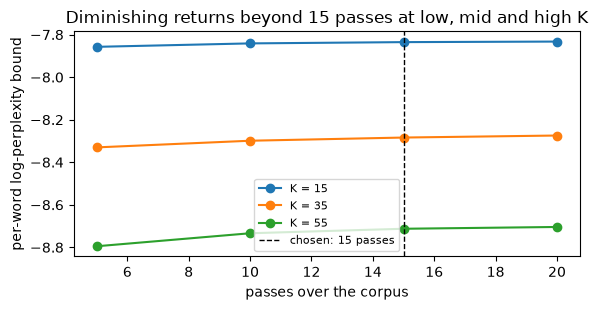

*Figure 1. LDA convergence: per-word log-perplexity bound against the number of passes for low, mid and high K (dashed line = the chosen 15 passes).*

In [9]:
# convergence study behind the training budget (stored: p03_conv_iterations.json, p03_conv_passes.json)
conv_iterations = load_json(DERIVED_DIR / "p03_conv_iterations.json")
conv_passes = load_json(DERIVED_DIR / "p03_conv_passes.json")

import datetime
for artifact in ["p03_conv_iterations.json", "p03_conv_passes.json", "p03_ksearch_models.csv", "p03_select.json", "p03_final_summary.json"]:
    modified = datetime.datetime.fromtimestamp((DERIVED_DIR / artifact).stat().st_mtime)
    print(f"{artifact:28s} last modified {modified:%Y-%m-%d %H:%M}")
print("(the convergence artifacts predate the K search and the selection)")

print(f"\nIterations probe (chunksize {conv_iterations['chunksize']}): share of documents converged within the iteration budget")
iterations_table = pd.DataFrame(conv_iterations["rows"]).rename(columns={"final_log_perplexity": "per-word log-perplexity bound"})
display(iterations_table.set_index(["K", "iterations", "passes"]))

print(f"\nPasses trajectory (iterations {conv_passes['iterations']}, chunksize {conv_passes['chunksize']}): per-word log-perplexity bound per number of passes")
passes_rows = []
for level, entry in conv_passes["K"].items():
    for n_passes, bound in entry["bounds"].items():
        passes_rows.append({"K": entry["K"], "passes": int(n_passes), "per-word log-perplexity bound": bound})
passes_table = pd.DataFrame(passes_rows).pivot(index="passes", columns="K", values="per-word log-perplexity bound")
display(passes_table.round(4))

print("\nStep-wise change between successive pass counts: Δ per-word log-perplexity bound and Hungarian-matched topic cosine (how much the topics still move)")
step_rows = []
for level, entry in conv_passes["K"].items():
    for step in entry["steps"]:
        step_rows.append({"K": entry["K"], "passes": f"{step['from']} → {step['to']}", "Δ per-word log-perplexity bound": step["d_log_perplexity"], "matched topic cosine": step["hungarian_topic_cosine"]})
display(pd.DataFrame(step_rows).set_index(["K", "passes"]))

fig, ax = plt.subplots(figsize=(6, 3.2))
for K_value in passes_table.columns:
    ax.plot(passes_table.index, passes_table[K_value], "o-", label=f"K = {K_value}")
ax.axvline(config.LDA_TRAINING["passes"], ls="--", color="k", lw=1, label=f"chosen: {config.LDA_TRAINING['passes']} passes")
ax.set_xlabel("passes over the corpus")
ax.set_ylabel("per-word log-perplexity bound")
ax.set_title("Diminishing returns beyond 15 passes at low, mid and high K")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
display(Markdown("*Figure 1. LDA convergence: per-word log-perplexity bound against the number of passes for low, mid and high K (dashed line = the chosen 15 passes).*"))

best median NPMI = 0.0514 → cutoff = 0.0414 → candidates K = [20, 25, 30] → selected K = 25 (highest median stability)


,median_NPMI,median_diversity,stability_P_median,stability_P_q1,stability_P_q3,candidate
K,,,,,,
10,0.0366,0.7400,0.6637,0.6291,0.6860,False
15,0.0413,0.7280,0.6193,0.5931,0.6414,False
20,0.0491,0.7080,0.6170,0.5981,0.6469,True
25,0.0514,0.7456,0.6274,0.6156,0.6662,True
30,0.0474,0.7333,0.5845,0.5614,0.6106,True
35,0.0370,0.7943,0.5571,0.5315,0.5861,False
40,0.0317,0.7860,0.5516,0.5366,0.5680,False
45,0.0179,0.8373,0.5431,0.5338,0.5607,False
50,0.0105,0.8640,0.5116,0.4926,0.5487,False


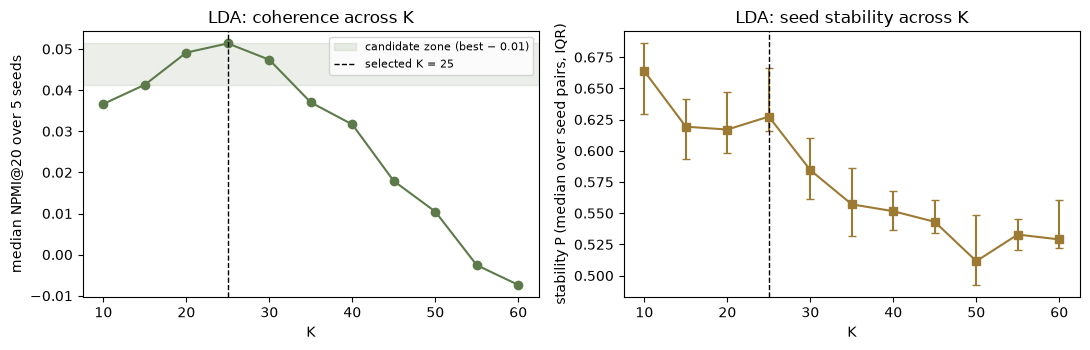

*Figure 2. LDA model selection over the K grid: median NPMI@20 (left; shaded = candidate zone within 0.01 of the best) and seed-pair stability P (right; median and IQR).*

In [10]:
# K search: 11 values of K × 5 seeds (stored: p03_ksearch_models.csv, p03_ksearch_stability.json, p03_select.json)
lda_runs = read_csv(DERIVED_DIR / "p03_ksearch_models.csv")
lda_stability = load_json(DERIVED_DIR / "p03_ksearch_stability.json")
lda_selection = load_json(DERIVED_DIR / "p03_select.json")

per_k = (lda_runs.groupby("K")
                 .agg(median_NPMI=("NPMI", "median"), median_diversity=("diversity", "median"))
                 .reset_index())
per_k["stability_P_median"] = [lda_stability[str(K)]["stability_median"] for K in per_k["K"]]
per_k["stability_P_q1"] = [lda_stability[str(K)]["stability_q1"] for K in per_k["K"]]
per_k["stability_P_q3"] = [lda_stability[str(K)]["stability_q3"] for K in per_k["K"]]

# the selection rule, recomputed here; the stored JSON only serves as a check
best_npmi = per_k["median_NPMI"].max()
cutoff = best_npmi - config.LDA_NPMI_TOLERANCE
per_k["candidate"] = per_k["median_NPMI"] >= cutoff
candidates = (per_k[per_k["candidate"]]
              .sort_values(["stability_P_median", "median_diversity", "K"], ascending=[False, False, True]))
selected_k = int(candidates.iloc[0]["K"])
print(f"best median NPMI = {best_npmi:.4f} → cutoff = {cutoff:.4f} → candidates K = {sorted(candidates['K'].tolist())} → selected K = {selected_k} (highest median stability)")
assert selected_k == lda_selection["selected_K"]
assert candidates["K"].tolist() == sorted(lda_selection["candidate_set"], key=lambda K: -lda_selection["candidate_stability"][str(K)])
display(per_k.set_index("K").round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(per_k["K"], per_k["median_NPMI"], "o-", color="#5C7A4A")
ax[0].axhspan(cutoff, best_npmi, color="#5C7A4A", alpha=0.12, label="candidate zone (best − 0.01)")
ax[0].axvline(selected_k, ls="--", color="k", lw=1, label=f"selected K = {selected_k}")
ax[0].set_xlabel("K")
ax[0].set_ylabel("median NPMI@20 over 5 seeds")
ax[0].set_title("LDA: coherence across K")
ax[0].legend(fontsize=8)
ax[1].errorbar(per_k["K"], per_k["stability_P_median"], yerr=[per_k["stability_P_median"] - per_k["stability_P_q1"], per_k["stability_P_q3"] - per_k["stability_P_median"]], fmt="s-", color="#9C7A33", capsize=3)
ax[1].axvline(selected_k, ls="--", color="k", lw=1)
ax[1].set_xlabel("K")
ax[1].set_ylabel("stability P (median over seed pairs, IQR)")
ax[1].set_title("LDA: seed stability across K")
plt.tight_layout()
plt.show()
display(Markdown("*Figure 2. LDA model selection over the K grid: median NPMI@20 (left; shaded = candidate zone within 0.01 of the best) and seed-pair stability P (right; median and IQR).*"))

In [11]:
# final LDA model: K = 25, ten seeds (stored: p03_final_summary.json)
lda_final = load_json(DERIVED_DIR / "p03_final_summary.json")


def median_iqr(entry, digits=4):
    return f"{entry['median']:.{digits}f} [{entry['q1']:.{digits}f}–{entry['q3']:.{digits}f}]"


lda_final_table = pd.DataFrame({
    "metric": ["NPMI@20 (canonical)", "C_v (canonical)", "topic diversity (top-25)", "stability P (45 seed pairs)"],
    "median [Q1–Q3] over 10 runs": [median_iqr(lda_final["metrics_over_10_runs"]["NPMI"]),
                                    median_iqr(lda_final["metrics_over_10_runs"]["C_v"]),
                                    median_iqr(lda_final["metrics_over_10_runs"]["diversity"]),
                                    median_iqr(lda_final["stability_over_45_pairs"])],
}).set_index("metric")
display(lda_final_table)

# medoid recomputed from the 45 stored seed-pair stabilities: highest mean pairwise P, then NPMI, then seed number
lda_pairwise = pd.DataFrame(lda_final["pairwise_P"])
lda_npmi_by_seed = {run["seed"]: run["NPMI"] for run in lda_final["runs"]}
lda_mean_p = {}
for seed in lda_final["seeds"]:
    pairs_of_seed = lda_pairwise[(lda_pairwise["a"] == seed) | (lda_pairwise["b"] == seed)]
    lda_mean_p[seed] = pairs_of_seed["P"].mean()
lda_medoid = sorted(lda_final["seeds"], key=lambda seed: (-lda_mean_p[seed], -lda_npmi_by_seed[seed], seed))[0]
assert len(lda_pairwise) == 45 and lda_medoid == lda_final["medoid_seed"]
display(pd.DataFrame({"seed": list(lda_mean_p), "mean pairwise P": list(lda_mean_p.values()), "NPMI": [lda_npmi_by_seed[s] for s in lda_mean_p]}).set_index("seed").round(4).T)
print(f"Medoid run: seed {lda_medoid} (mean pairwise P = {lda_mean_p[lda_medoid]:.4f}); K = {lda_final['selected_K']}; "
      "the medoid's document–topic matrix θ is used in RQ1–RQ3.")

,median [Q1–Q3] over 10 runs
metric,
NPMI@20 (canonical),0.0496 [0.0468–0.0517]
C_v (canonical),0.5174 [0.5121–0.5234]
topic diversity (top-25),0.7360 [0.7228–0.7480]
stability P (45 seed pairs),0.6232 [0.5959–0.6550]


seed,0,1,2,3,4,5,6,7,8,9
mean pairwise P,0.6293,0.6233,0.6611,0.6204,0.6267,0.6227,0.6087,0.6175,0.6025,0.627
NPMI,0.0518,0.0466,0.0520,0.0514,0.0495,0.0474,0.0497,0.0437,0.0465,0.052


Medoid run: seed 2 (mean pairwise P = 0.6611); K = 25; the medoid's document–topic matrix θ is used in RQ1–RQ3.


## 4. BERTopic: model selection and final model

In [12]:
# BERTopic protocol (read from analysis_config.py; the same constants drive p04_bertopic.py)
import math

N_MAIN = 106524
mcs_grid = sorted({max(config.MCS_FLOOR, math.ceil(fraction * N_MAIN)) for fraction in config.MCS_FRACTIONS})
bertopic_protocol = {
    "embedding model": f"{config.EMBED_MODEL} @ {config.EMBED_REVISION} (local_files_only)",
    "embedding input": config.EMBED_INPUT,
    "max sequence length (word-pieces)": config.EMBED_MAX_TOKENS,
    "long documents": "non-overlapping token chunks (stride 0) → weighted mean by content-token count → L2 normalisation",
    "UMAP": {**config.UMAP_PARAMS, "random_state": "seed"},
    "HDBSCAN": {"min_cluster_size": "grid (below)", "min_samples": config.HDBSCAN_MIN_SAMPLES, "metric": config.HDBSCAN_PARAMS["metric"],
                "cluster_selection_method": config.HDBSCAN_PARAMS["cluster_selection_method"], "prediction_data": "True for the final model only"},
    "mcs grid": f"max({config.MCS_FLOOR}, ceil(fraction × N)) for fractions {config.MCS_FRACTIONS} → {mcs_grid}",
    "seeds, mcs search": config.BERTOPIC_SEEDS,
    "seeds, final model (added)": config.BERTOPIC_SEEDS_FINAL,
    "post-hoc topic reduction": config.BERTOPIC_TOPIC_REDUCTION,
    "outliers": "label −1 kept as outliers (never reassigned); excluded from topic metrics",
    "native representation (interpretation only)": {"vectorizer": {"lowercase": True, "ngram_range": (1, 2), "min_df": load_json(DERIVED_DIR / "p04_final_summary.json")["native_min_df"],
                                                                    "stop_words": "explicit English stop-list + domain stop-list", "tokenizer": "surface tokens with the same technical token filter (tech_ok) as LDA; no lemmatisation or POS filtering"},
                                                     "c-TF-IDF": config.BERTOPIC_CTFIDF},
    "canonical evaluation": "shared canonical token space used by LDA and BERTopic; per-topic canonical c-TF-IDF terms",
    "NPMI (primary)": f"mean per-topic c_npmi over non-outlier topics, top {config.COH_TOPN}, window {config.COH_NPMI_WINDOW}",
    "C_v (final runs only)": f"top {config.COH_TOPN}, window {config.COH_CV_WINDOW}",
    "topic diversity": f"unique terms among the top {config.DIV_TOPN} canonical terms of all topics",
    "stability": "weighted canonical top-50 → cosine → Hungarian → P = sum matched cosine / max(K_i, K_j)",
    "candidate tolerance (NPMI)": config.LDA_NPMI_TOLERANCE,
}
for key, value in bertopic_protocol.items():
    print(f"{key:44s} {value}")
assert mcs_grid == [54, 107, 214, 373, 533, 799, 1066]

if RUN_HEAVY:
    # actual p04 stages: chunked MiniLM embeddings of all MAIN documents, 35 clusterings (7 mcs × 5 seeds), coherence, selection, 10 final runs (hours)
    for stage in ["embeddings", "cluster_search", "cluster_metrics", "select", "final"]:
        subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p04_bertopic.py", "--stage", stage], check=True)

# the implementation of chunked embedding, the relative grid, pairwise stability and the selection rule
show_source(SCRIPTS_DIR / "p04_bertopic.py", ["_load_model", "_chunk_ids", "_embed_docs", "_mcs_grid", "_canonical_ctfidf_topics", "_native_ctfidf_topics", "_pairwise_PAC", "stage_select"])

embedding model                              all-MiniLM-L6-v2 @ 1110a243fdf4706b3f48f1d95db1a4f5529b4d41 (local_files_only)
embedding input                              clean_text
max sequence length (word-pieces)            256
long documents                               non-overlapping token chunks (stride 0) → weighted mean by content-token count → L2 normalisation
UMAP                                         {'n_neighbors': 15, 'n_components': 5, 'min_dist': 0.0, 'metric': 'cosine', 'random_state': 'seed'}
HDBSCAN                                      {'min_cluster_size': 'grid (below)', 'min_samples': 10, 'metric': 'euclidean', 'cluster_selection_method': 'eom', 'prediction_data': 'True for the final model only'}
mcs grid                                     max(25, ceil(fraction × N)) for fractions [0.0005, 0.001, 0.002, 0.0035, 0.005, 0.0075, 0.01] → [54, 107, 214, 373, 533, 799, 1066]
seeds, mcs search                            [0, 1, 2, 3, 4]
seeds, final model (added)        

In [13]:
# document length vs. the 256-word-piece limit and the resulting chunking (stored: p04_embedding_diag.json, p04_chunk_diag.json)
embedding_diag = load_json(DERIVED_DIR / "p04_embedding_diag.json")
chunk_diag = load_json(DERIVED_DIR / "p04_chunk_diag.json")
print(f"Documents: {embedding_diag['N_documents']:,} | token length median {embedding_diag['token_length']['median']}, "
      f"p90 {embedding_diag['token_length']['p90']}, max {embedding_diag['token_length']['max']:,}")
print(f"Documents longer than {embedding_diag['model_max_seq_length']} word-pieces: {embedding_diag['over_max_seq_256']['N']:,} "
      f"({embedding_diag['over_max_seq_256']['pct']:.2f} %) → chunked; total chunks {chunk_diag['total_chunks']:,} "
      f"(median {chunk_diag['chunks_per_doc']['median']}, p99 {chunk_diag['chunks_per_doc']['p99']}, max {chunk_diag['chunks_per_doc']['max']} per document)")
display(pd.DataFrame({"chunks per document": list(chunk_diag["hist_docs_by_nchunks"]), "documents": list(chunk_diag["hist_docs_by_nchunks"].values())}).set_index("chunks per document").T)

Documents: 106,524 | token length median 249, p90 435, max 10,890
Documents longer than 256 word-pieces: 50,118 (47.05 %) → chunked; total chunks 173,319 (median 1, p99 5, max 43 per document)


chunks per document,1,2,3,4,5,6+
documents,56406,43037,3846,1920,384,931


best median NPMI = 0.0762 → cutoff = 0.0662 → candidates mcs = [107, 214, 373] → selected mcs = 107 (highest median stability P)


,median_NPMI,median_diversity,median_topics,median_outlier_share,any_degenerate,stability_P_median,candidate
mcs,,,,,,,
54,0.0597,0.4889,268.0,0.4421,False,0.8485,False
107,0.0762,0.4792,152.0,0.4199,False,0.8852,True
214,0.0758,0.4988,80.0,0.3664,False,0.8280,True
373,0.0699,0.4992,50.0,0.3910,False,0.8522,True
533,0.0630,0.5226,32.0,0.4046,False,0.8181,False
799,0.0521,0.5533,24.0,0.4199,False,0.8410,False
1066,0.0498,0.5660,20.0,0.4109,False,0.8773,False


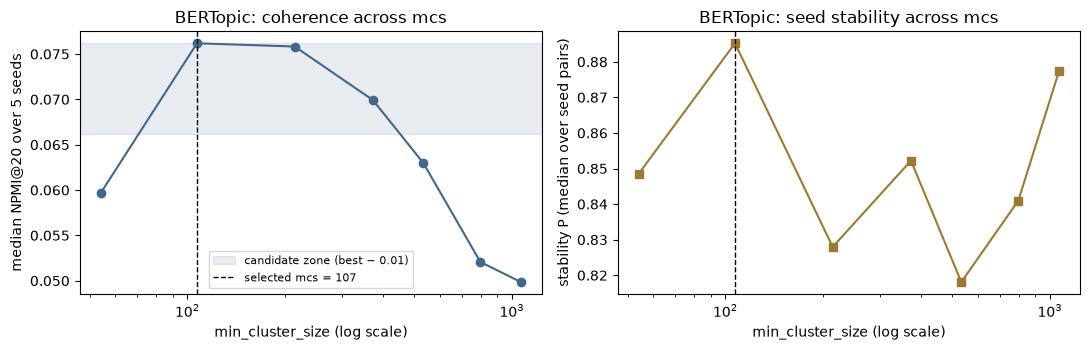

*Figure 3. BERTopic model selection over the relative min_cluster_size grid: median NPMI@20 (left; shaded = candidate zone) and seed-pair stability P (right).*

In [14]:
# mcs search: 7 values × 5 seeds (stored: p04_cluster_models.csv, p04_cluster_stability.json, p04_select.json)
bertopic_runs = read_csv(DERIVED_DIR / "p04_cluster_models.csv")
bertopic_stability = load_json(DERIVED_DIR / "p04_cluster_stability.json")
bertopic_selection = load_json(DERIVED_DIR / "p04_select.json")

per_mcs = (bertopic_runs.groupby("mcs")
                        .agg(median_NPMI=("NPMI", "median"),
                             median_diversity=("diversity", "median"),
                             median_topics=("n_topics", "median"),
                             median_outlier_share=("outlier_share", "median"),
                             any_degenerate=("degenerate", "any"))
                        .reset_index())
per_mcs["stability_P_median"] = [bertopic_stability[str(mcs)]["P"] for mcs in per_mcs["mcs"]]

# the selection rule, recomputed here; the stored JSON only serves as a check
valid = ~per_mcs["any_degenerate"]
best_npmi_ber = per_mcs.loc[valid, "median_NPMI"].max()
cutoff_ber = best_npmi_ber - config.LDA_NPMI_TOLERANCE
per_mcs["candidate"] = valid & (per_mcs["median_NPMI"] >= cutoff_ber)
candidates_ber = (per_mcs[per_mcs["candidate"]]
                  .sort_values(["stability_P_median", "median_diversity", "median_topics", "mcs"], ascending=[False, False, True, False]))
selected_mcs = int(candidates_ber.iloc[0]["mcs"])
print(f"best median NPMI = {best_npmi_ber:.4f} → cutoff = {cutoff_ber:.4f} → candidates mcs = {sorted(candidates_ber['mcs'].tolist())} → selected mcs = {selected_mcs} (highest median stability P)")
assert selected_mcs == bertopic_selection["selected_mcs"]
assert sorted(candidates_ber["mcs"].tolist()) == sorted(bertopic_selection["candidate_set"])
display(per_mcs.set_index("mcs").round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(per_mcs["mcs"], per_mcs["median_NPMI"], "o-", color="#43678A")
ax[0].axhspan(cutoff_ber, best_npmi_ber, color="#43678A", alpha=0.12, label="candidate zone (best − 0.01)")
ax[0].axvline(selected_mcs, ls="--", color="k", lw=1, label=f"selected mcs = {selected_mcs}")
ax[0].set_xscale("log")
ax[0].set_xlabel("min_cluster_size (log scale)")
ax[0].set_ylabel("median NPMI@20 over 5 seeds")
ax[0].set_title("BERTopic: coherence across mcs")
ax[0].legend(fontsize=8)
ax[1].plot(per_mcs["mcs"], per_mcs["stability_P_median"], "s-", color="#9C7A33")
ax[1].axvline(selected_mcs, ls="--", color="k", lw=1)
ax[1].set_xscale("log")
ax[1].set_xlabel("min_cluster_size (log scale)")
ax[1].set_ylabel("stability P (median over seed pairs)")
ax[1].set_title("BERTopic: seed stability across mcs")
plt.tight_layout()
plt.show()
display(Markdown("*Figure 3. BERTopic model selection over the relative min_cluster_size grid: median NPMI@20 (left; shaded = candidate zone) and seed-pair stability P (right).*"))

In [15]:
# final BERTopic model: mcs = 107, ten seeds (stored: p04_final_summary.json)
bertopic_final = load_json(DERIVED_DIR / "p04_final_summary.json")
metrics_10 = bertopic_final["metrics_over_10"]
bertopic_final_table = pd.DataFrame({
    "metric": ["NPMI@20 (canonical, non-outlier topics)", "C_v (canonical)", "topic diversity (top-25)", "number of topics", "outlier share", "stability P (45 seed pairs)"],
    "median [Q1–Q3] over 10 runs": [median_iqr(metrics_10["NPMI"]), median_iqr(metrics_10["C_v"]), median_iqr(metrics_10["diversity"]),
                                    f"{metrics_10['n_topics']['median']:.0f} [{metrics_10['n_topics']['q1']:.1f}–{metrics_10['n_topics']['q3']:.1f}]",
                                    median_iqr(metrics_10["outlier_share"]), median_iqr(bertopic_final["stability_over_45"])],
}).set_index("metric")
display(bertopic_final_table)

# medoid recomputed from the 45 stored seed-pair stabilities (p04_final_pairwise.json): highest mean pairwise P, then NPMI, then seed number
bertopic_pairwise = pd.DataFrame(load_json(DERIVED_DIR / "p04_final_pairwise.json"))
bertopic_final_runs = read_csv(DERIVED_DIR / "p04_final_runs.csv")
bertopic_npmi_by_seed = dict(zip(bertopic_final_runs["seed"], bertopic_final_runs["NPMI"]))
bertopic_mean_p = {}
for seed in sorted(bertopic_final_runs["seed"]):
    pairs_of_seed = bertopic_pairwise[(bertopic_pairwise["a"] == seed) | (bertopic_pairwise["b"] == seed)]
    bertopic_mean_p[seed] = pairs_of_seed["P"].mean()
bertopic_medoid = sorted(bertopic_mean_p, key=lambda seed: (-bertopic_mean_p[seed], -bertopic_npmi_by_seed[seed], seed))[0]
assert len(bertopic_pairwise) == 45 and bertopic_medoid == bertopic_final["medoid_seed"]
display(pd.DataFrame({"seed": list(bertopic_mean_p), "mean pairwise P": list(bertopic_mean_p.values()), "NPMI": [bertopic_npmi_by_seed[s] for s in bertopic_mean_p]}).set_index("seed").round(4).T)
print(f"Medoid run (used in RQ1–RQ3): seed {bertopic_medoid} (mean pairwise P = {bertopic_mean_p[bertopic_medoid]:.4f}); "
      f"{bertopic_final['n_nonoutlier_clusters']} topics, outlier share {bertopic_final['medoid_outlier_share']:.4f} — "
      f"these medoid values differ from the medians over the ten runs reported above.")
print("Soft memberships (for RQ3): HDBSCAN all_points_membership_vectors over the non-outlier clusters of the medoid run — not an LDA-style θ; label −1 remains a hard outlier.")

,median [Q1–Q3] over 10 runs
metric,
"NPMI@20 (canonical, non-outlier topics)",0.0760 [0.0753–0.0774]
C_v (canonical),0.5687 [0.5680–0.5737]
topic diversity (top-25),0.4759 [0.4708–0.4800]
number of topics,152 [148.5–153.8]
outlier share,0.4146 [0.4030–0.4212]
stability P (45 seed pairs),0.8642 [0.8587–0.8733]


seed,0,1,2,3,4,5,6,7,8,9
mean pairwise P,0.8680,0.8803,0.8603,0.8722,0.8808,0.8688,0.8621,0.8600,0.8595,0.8621
NPMI,0.0762,0.0758,0.0777,0.0753,0.0777,0.0753,0.0784,0.0767,0.0706,0.0754


Medoid run (used in RQ1–RQ3): seed 4 (mean pairwise P = 0.8808); 153 topics, outlier share 0.4341 — these medoid values differ from the medians over the ten runs reported above.
Soft memberships (for RQ3): HDBSCAN all_points_membership_vectors over the non-outlier clusters of the medoid run — not an LDA-style θ; label −1 remains a hard outlier.


## 5. RQ1 — Thematic structure of the field

In [16]:
# human labelling packet (stored: labeling/p10_labeling_meta.json, p10_labels_final.csv)
labelling_meta = load_json(DERIVED_DIR / "labeling" / "p10_labeling_meta.json")
topic_labels = read_csv(DERIVED_DIR / "labeling" / "p10_labels_final.csv")
n_escalated = int((topic_labels["escalated"] == True).sum())
print(f"Topics labelled: {labelling_meta['n_topics']} ({labelling_meta['n_lda']} LDA + {labelling_meta['n_ber']} BERTopic); "
      f"model-masked random order, mask seed {labelling_meta['mask_seed']}")
print(f"Evidence per topic: top {labelling_meta['base_terms']} native terms + {labelling_meta['rep_docs']} representative documents; "
      f"escalation to {labelling_meta['escalation']['escalated']['terms']} terms + {labelling_meta['escalation']['escalated']['docs_extra']} further documents for {n_escalated} ambiguous topics")
assert len(topic_labels) == 178 and topic_labels["final_label"].notna().all()
assert n_escalated == 7
labelling_protocol = {
    "representative documents, LDA": "top documents by θ of the topic (medoid seed 2)",
    "representative documents, BERTopic": "top documents by soft membership of the topic (medoid seed 4); outlier label −1 was not labelled",
    "evidence terms": "LDA: top lemma/phrase terms of β; BERTopic: top native c-TF-IDF terms",
    "blinding caveat (frozen)": "model masking hides the model name, but full blinding is not guaranteed: LDA evidence shows lemma/phrase forms, BERTopic evidence shows surface forms",
    "labels frozen before RQ5": True,
}
for key, value in labelling_protocol.items():
    print(f"{key:36s} {value}")

if RUN_HEAVY:
    # rebuilds the model-masked evidence packet only; it does NOT reproduce the human labels, which are a frozen manual-coding artifact
    subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p10_build_labeling.py"], check=True)

# how representative documents were ranked (printed from the module itself)
show_source(SCRIPTS_DIR / "p10_build_labeling.py", ["rep_lda", "rep_ber"])
label_of = {}
for model in ["LDA", "BERTopic"]:
    subset = topic_labels[topic_labels["model"] == model]
    label_of[model] = dict(zip(subset["real_topic_id"], subset["final_label"]))
clarity = topic_labels.groupby(["model", "clarity_flag"]).size().unstack(fill_value=0)
print("\nLabel clarity (human judgement):")
display(clarity)

Topics labelled: 178 (25 LDA + 153 BERTopic); model-masked random order, mask seed 777
Evidence per topic: top 15 native terms + 10 representative documents; escalation to 20 terms + 10 further documents for 7 ambiguous topics
representative documents, LDA        top documents by θ of the topic (medoid seed 2)
representative documents, BERTopic   top documents by soft membership of the topic (medoid seed 4); outlier label −1 was not labelled
evidence terms                       LDA: top lemma/phrase terms of β; BERTopic: top native c-TF-IDF terms
blinding caveat (frozen)             model masking hides the model name, but full blinding is not guaranteed: LDA evidence shows lemma/phrase forms, BERTopic evidence shows surface forms
labels frozen before RQ5             True
# ---- p10_build_labeling.py: rep_lda ----
def rep_lda(k, n): return [ldk[i] for i in np.argsort(-np.nan_to_num(A[:, k], nan=-1.0))[:n]]

# ---- p10_build_labeling.py: rep_ber ----
def rep_ber(l, n): return [bdk[i] for


Label clarity (human judgement):


clarity_flag,clear,mixed
model,,
BERTopic,142,11
LDA,16,9


In [17]:
# LDA topics with prevalence = mean θ over documents with a non-empty representation (stored: p03_theta_main.parquet, p03_medoid_topics.csv)
theta = pq.read_table(DERIVED_DIR / "p03_theta_main.parquet").to_pandas()
theta_columns = [column for column in theta.columns if column.startswith("theta_")]
theta_topics = [int(column.split("_")[1]) for column in theta_columns]      # theta_k → topic k
assert theta_topics == list(range(25))
lda_prevalence = theta[theta_columns].mean(axis=0, skipna=True).to_numpy()
assert theta[theta_columns].notna().all(axis=1).sum() == 106501
assert np.isclose(lda_prevalence.sum(), 1.0, atol=1e-5)

lda_terms = read_csv(DERIVED_DIR / "p03_medoid_topics.csv")
top_terms_of_lda = {}
for topic_id, terms in zip(lda_terms["topic_id"], lda_terms["top_terms"]):
    top_terms_of_lda[topic_id] = ", ".join(terms.split(", ")[:8])

rq1_lda = topic_labels[topic_labels["model"] == "LDA"].copy()
rq1_lda = rq1_lda.rename(columns={"real_topic_id": "topic"})
rq1_lda["prevalence_pct"] = [100 * lda_prevalence[topic] for topic in rq1_lda["topic"]]
rq1_lda["top_terms"] = [top_terms_of_lda[topic] for topic in rq1_lda["topic"]]
rq1_lda = rq1_lda[["topic", "final_label", "description", "prevalence_pct", "top_terms"]].sort_values("prevalence_pct", ascending=False)
assert len(rq1_lda) == 25
print("LDA — all 25 topics (mean topic probability, %):")
display(rq1_lda.set_index("topic").round(2))

LDA — all 25 topics (mean topic probability, %):


,final_label,description,prevalence_pct,top_terms
topic,,,,
11,General and Conceptual Entrepreneurship Residual Cluster,"A heterogeneous residual cluster of general, conceptual, editorial, and meta-level entrepreneurship documents rather...",12.63,"new, work, way, change, opportunity, issue, field, world"
9,Conceptual and Theoretical Entrepreneurship Research,"A mixed cluster of conceptual, theoretical, and meta-level entrepreneurship research, including frameworks, nascent ...",9.05,"approach, finding, context, literature, analysis, theory, implication, framework"
18,"Entrepreneurship, Economic Development and Regional Policy","Research on the relationship between entrepreneurship, economic and regional development, government policy, institu...",8.47,"development, policy, country, economic, economy, sector, growth, level"
5,Entrepreneurial Cognition and Individual Differences,"Research on individual psychological and cognitive factors in entrepreneurship, including risk perception, personali...",6.80,"factor, individual, characteristic, venture, effect, success, opportunity, level"
20,Instructional Models and Learning Materials in Entrepreneurship Education,"A mixed cluster on instructional models and learning materials in entrepreneurship education, held together by share...",6.27,"model, project, design, learning, development, method, process, competency"
6,"Entrepreneurship Development, Regulation and State Support","Research on entrepreneurship development, regulation, and state support, including institutional conditions, competi...",4.52,"development, activity, economic, system, enterprise, state, condition, formation"
13,Business and Marketing Case Studies,A mixed cluster grouping business and marketing teaching case studies and applied business/marketing material rather...,4.16,"market, product, company, marketing, case, production, customer, consumer"
14,Entrepreneurial Intentions among University Students,"Research on entrepreneurial intentions among university students, including self-efficacy, attitudes, the theory of ...",3.99,"student, university, entrepreneurial_intention, intention, self_efficacy, entrepreneurship_education, academic, course"
3,Innovation and Entrepreneurship Education Reform in China,"Research on innovation and entrepreneurship education reform in China, including college curriculum, teaching system...",3.83,"education, entrepreneurship_education, school, student, educational, teacher, curriculum, teaching"


In [18]:
# BERTopic topics with share = hard-assigned documents / all MAIN documents (stored: p04_medoid_labels.parquet, p04_medoid_native.csv)
hard_labels = pq.read_table(DERIVED_DIR / "p04_medoid_labels.parquet").to_pandas()["hard_label"].to_numpy()
n_documents = len(hard_labels)
outlier_share = float((hard_labels == -1).mean())
native_terms = read_csv(DERIVED_DIR / "p04_medoid_native.csv")
top_terms_of_bertopic = {}
for cluster, terms in zip(native_terms["cluster"], native_terms["top_native"]):
    top_terms_of_bertopic[cluster] = ", ".join(terms.split(", ")[:8])

rq1_ber = topic_labels[topic_labels["model"] == "BERTopic"].copy()
rq1_ber = rq1_ber.rename(columns={"real_topic_id": "topic"})
rq1_ber["size"] = [int((hard_labels == topic).sum()) for topic in rq1_ber["topic"]]
rq1_ber["share_pct"] = 100 * rq1_ber["size"] / n_documents
rq1_ber["top_terms"] = [top_terms_of_bertopic[topic] for topic in rq1_ber["topic"]]
rq1_ber = rq1_ber[["topic", "final_label", "description", "size", "share_pct", "top_terms"]].sort_values("size", ascending=False)
assert len(rq1_ber) == 153 and n_documents == 106524
assert np.isclose(rq1_ber["share_pct"].sum() / 100 + outlier_share, 1.0, atol=1e-9)
print(f"BERTopic — 20 largest of 153 topics (share of all {n_documents:,} MAIN documents, %; outliers = {100 * outlier_share:.1f} %); full list in Appendix A:")
display(rq1_ber.set_index("topic").head(20).round(2))

BERTopic — 20 largest of 153 topics (share of all 106,524 MAIN documents, %; outliers = 43.4 %); full list in Appendix A:


,final_label,description,size,share_pct,top_terms
topic,,,,,
14,Green and Sustainable Entrepreneurship,"Research on green and sustainable entrepreneurship, including sustainability orientation, green ventures, renewable ...",2898,2.72,"green, sustainable, environmental, sustainability, energy, sustainable entrepreneurship, green entrepreneurship, sus..."
12,Tourism Entrepreneurship and Rural Tourism,"Research on tourism entrepreneurship and rural tourism, including agritourism, ecotourism, hospitality, and small to...",2092,1.96,"tourism, tourist, hospitality, local, rural tourism, rural, tourism entrepreneurship, heritage"
87,Innovation and Entrepreneurship Training in Colleges and Universities,"Research on innovation and entrepreneurship training in colleges and universities, including training systems, vocat...",1918,1.80,"innovation entrepreneurship, college, entrepreneurship education, education, colleges, innovation, vocational, talents"
152,Entrepreneurial Intentions and Self-Efficacy,"Research on entrepreneurial intentions and self-efficacy, including attitudes, perceived behavioral control, and the...",1913,1.80,"intention, entrepreneurial intention, self-efficacy, intentions, entrepreneurial intentions, students, entrepreneurs..."
72,Social Entrepreneurship and Social Enterprises,"Research on social entrepreneurship and social enterprises, including work-integration social enterprises, social ec...",1834,1.72,"social, social entrepreneurship, social enterprises, enterprises, social enterprise, development social, social entr..."
62,Ethnic and Immigrant Entrepreneurship,"Research on ethnic and immigrant entrepreneurship, including immigrant, minority, Black, and diaspora entrepreneurs ...",1829,1.72,"ethnic, immigrant, black, immigrants, migration, migrant, transnational, migrants"
143,Pedagogy and Experiential Learning in Entrepreneurship Education,"Research on pedagogy and experiential learning in entrepreneurship education, including experiential pedagogies, com...",1464,1.37,"education, entrepreneurship education, learning, teaching, educational, students, ee, teachers"
90,African Entrepreneurship and Informal Economies,"A mixed cluster on African entrepreneurship and informal economies, including the informal sector, innovation hubs, ...",1230,1.15,"africa, african, informal, south, south africa, hubs, innovation hubs, growth"
20,Healthcare and Medical Entrepreneurship,"Research on entrepreneurship in healthcare and medicine, including medical/physician entrepreneurship, healthcare in...",1167,1.10,"health, medical, care, clinical, healthcare, patients, medicine, health care"


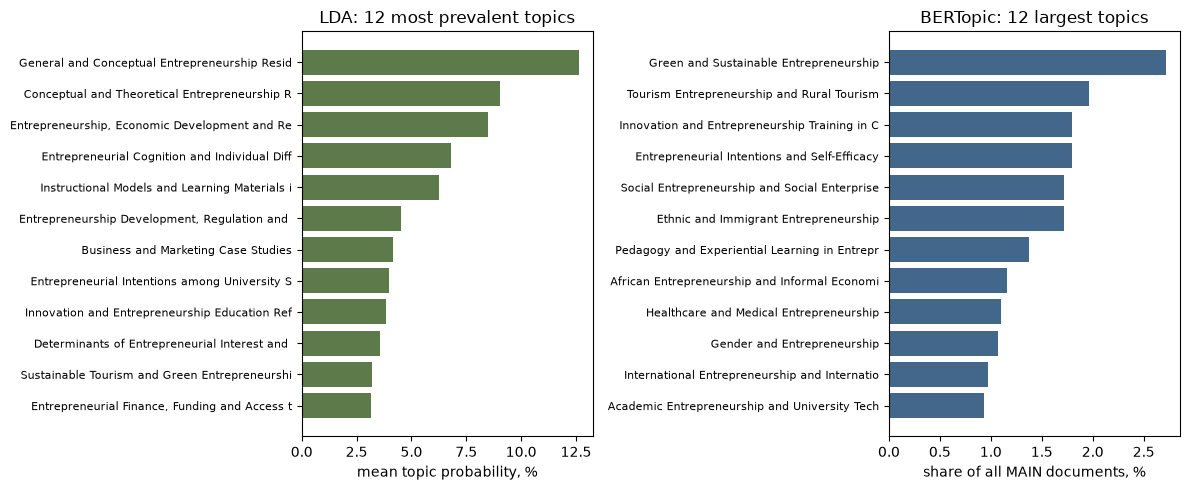

*Figure 4. RQ1: the 12 most prevalent LDA topics (mean topic probability, %) and the 12 largest BERTopic topics (share of MAIN documents, %).*

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_lda = rq1_lda.sort_values("prevalence_pct").tail(12)
axes[0].barh(top_lda["final_label"].str.slice(0, 45), top_lda["prevalence_pct"], color="#5C7A4A")
axes[0].set_title("LDA: 12 most prevalent topics")
axes[0].set_xlabel("mean topic probability, %")
axes[0].tick_params(axis="y", labelsize=8)
top_ber = rq1_ber.sort_values("share_pct").tail(12)
axes[1].barh(top_ber["final_label"].str.slice(0, 45), top_ber["share_pct"], color="#43678A")
axes[1].set_title("BERTopic: 12 largest topics")
axes[1].set_xlabel("share of all MAIN documents, %")
axes[1].tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()
display(Markdown("*Figure 4. RQ1: the 12 most prevalent LDA topics (mean topic probability, %) and the 12 largest BERTopic topics (share of MAIN documents, %).*"))

## 6. RQ2 — Dynamics over time (2000–2025)

Documents per year: 357 in 2000 → 10150 in 2025
BERTopic outlier share: 40.6 % in 2000 → 43.7 % in 2025; early mean (2000–04) 41.6 %, late mean (2021–25) 43.4 %


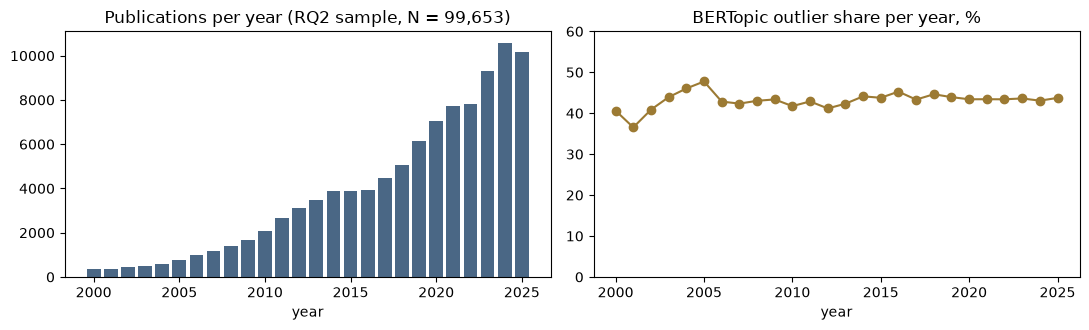

*Figure 5. RQ2 sample: publications per year (left) and the BERTopic outlier share per year, % (right).*

In [20]:
# RQ2 sample and per-year totals (stored: p06_rq2_summary.json, p06_year_N.csv)
rq2_summary = load_json(DERIVED_DIR / "p06_rq2_summary.json")
year_totals = read_csv(DERIVED_DIR / "p06_year_N.csv")
years = [str(year) for year in range(2000, 2026)]
assert year_totals["year"].tolist() == list(range(2000, 2026))
assert year_totals["N_BER"].sum() == 99653 == rq2_summary["sample_rq2"]
assert year_totals["N_LDA"].sum() == 99632 == rq2_summary["lda_usable_rq2"]
first_year = year_totals.iloc[0]
last_year = year_totals.iloc[-1]
print(f"Documents per year: {int(first_year['N_BER'])} in {int(first_year['year'])} → {int(last_year['N_BER'])} in {int(last_year['year'])}")
print(f"BERTopic outlier share: {100 * first_year['outlier_share']:.1f} % in {int(first_year['year'])} → {100 * last_year['outlier_share']:.1f} % in {int(last_year['year'])}; "
      f"early mean (2000–04) {100 * rq2_summary['outlier_share_2000_2004']:.1f} %, late mean (2021–25) {100 * rq2_summary['outlier_share_2021_2025']:.1f} %")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(year_totals["year"], year_totals["N_BER"], color="#4A6785")
axes[0].set_title(f"Publications per year (RQ2 sample, N = {rq2_summary['sample_rq2']:,})")
axes[0].set_xlabel("year")
axes[1].plot(year_totals["year"], 100 * year_totals["outlier_share"], "o-", color="#9C7A33")
axes[1].set_ylim(0, 60)
axes[1].set_title("BERTopic outlier share per year, %")
axes[1].set_xlabel("year")
plt.tight_layout()
plt.show()
display(Markdown("*Figure 5. RQ2 sample: publications per year (left) and the BERTopic outlier share per year, % (right).*"))

In [21]:
# annual prevalence recomputed from the primary stored outputs (corpus_final.parquet, p03_theta_main.parquet, p04_medoid_labels.parquet)
# and checked against the stored matrices of p06 (p06_{lda,ber}_prevalence.csv)
corpus_years = pq.read_table(DERIVED_DIR / "corpus_final.parquet", columns=["openalex_id", "analytic_main", "year_valid_for_rq2", "year_final"],
                             filters=[("analytic_main", "=", True)]).to_pandas()
in_rq2 = corpus_years["year_valid_for_rq2"] & corpus_years["year_final"].between(2000, 2025)
year_of = dict(zip(corpus_years.loc[in_rq2, "openalex_id"], corpus_years.loc[in_rq2, "year_final"].astype(int)))
assert len(year_of) == 99653

# LDA: mean θ per year over documents with a non-empty representation (θ of the medoid run, loaded in RQ1)
theta_rq2 = theta[theta["openalex_id"].isin(year_of)].copy()
theta_rq2 = theta_rq2[theta_rq2[theta_columns[0]].notna()]
theta_rq2["year"] = [year_of[document_id] for document_id in theta_rq2["openalex_id"]]
assert len(theta_rq2) == 99632
recomputed_lda = theta_rq2.groupby("year")[theta_columns].mean().T          # 25 topics × 26 years
recomputed_lda.columns = [str(year) for year in recomputed_lda.columns]
recomputed_lda.index = theta_topics                                          # rows were the θ column names → topic ids

# BERTopic: share of each year's documents hard-assigned to the topic (all documents of the year in the denominator)
medoid_labels = pq.read_table(DERIVED_DIR / "p04_medoid_labels.parquet").to_pandas()
medoid_labels = medoid_labels[medoid_labels["openalex_id"].isin(year_of)].copy()
medoid_labels["year"] = [year_of[document_id] for document_id in medoid_labels["openalex_id"]]
assert len(medoid_labels) == 99653
documents_per_year = medoid_labels.groupby("year").size()
recomputed_ber = pd.DataFrame(index=range(153), columns=years, dtype=float)
recomputed_outlier_share = pd.Series(index=years, dtype=float)
for year in range(2000, 2026):
    labels_of_year = medoid_labels.loc[medoid_labels["year"] == year, "hard_label"]
    counts = labels_of_year.value_counts()
    for topic in range(153):
        recomputed_ber.loc[topic, str(year)] = counts.get(topic, 0) / documents_per_year[year]
    recomputed_outlier_share[str(year)] = counts.get(-1, 0) / documents_per_year[year]

lda_prevalence_by_year = read_csv(DERIVED_DIR / "p06_lda_prevalence.csv")
ber_prevalence_by_year = read_csv(DERIVED_DIR / "p06_ber_prevalence.csv")
assert len(lda_prevalence_by_year) == 25 and len(ber_prevalence_by_year) == 153
lda_difference = np.max(np.abs(recomputed_lda.to_numpy() - lda_prevalence_by_year.sort_values("topic")[years].to_numpy()))
ber_difference = np.max(np.abs(recomputed_ber.to_numpy() - ber_prevalence_by_year.sort_values("topic")[years].to_numpy()))
outlier_difference = np.max(np.abs(recomputed_outlier_share.to_numpy() - year_totals["outlier_share"].to_numpy()))
print(f"LDA annual prevalence: max |difference| = {lda_difference:.2e} (θ is stored as float32)")
print(f"BERTopic annual prevalence: max |difference| = {ber_difference:.2e}; outlier share: max |difference| = {outlier_difference:.2e}")
assert lda_difference < 1e-7 and ber_difference < 1e-12 and outlier_difference < 1e-12
assert np.allclose(lda_prevalence_by_year[years].sum(axis=0), 1.0, atol=1e-5)
assert np.allclose(ber_prevalence_by_year[years].sum(axis=0).to_numpy() + year_totals["outlier_share"].to_numpy(), 1.0, atol=1e-5)
print("Annual prevalence recomputed from θ / hard labels matches the stored p06 matrices (LDA 25 × 26 within float32 precision, BERTopic 153 × 26 and outlier share exactly).")

LDA annual prevalence: max |difference| = 1.49e-08 (θ is stored as float32)
BERTopic annual prevalence: max |difference| = 9.89e-17; outlier share: max |difference| = 5.55e-17
Annual prevalence recomputed from θ / hard labels matches the stored p06 matrices (LDA 25 × 26 within float32 precision, BERTopic 153 × 26 and outlier share exactly).


In [22]:
# descriptive trend statistics recomputed in the notebook and checked against p06_{lda,ber}_trends.csv
from scipy.stats import kendalltau, theilslopes

year_values = np.array([int(year) for year in years])


def calculate_trends(prevalence_matrix):
    rows = []
    for topic, series in prevalence_matrix.iterrows():
        values = series[years].to_numpy(dtype=float)
        tau = kendalltau(year_values, values).correlation
        slope = theilslopes(values, year_values)[0]
        early = values[:5].mean()          # 2000–2004
        late = values[-5:].mean()          # 2021–2025
        rows.append({"topic": int(topic), "kendall_tau": tau, "theil_sen_slope_pp_per_yr": 100 * slope,
                     "mean_prev_2000_2004": early, "mean_prev_2021_2025": late, "delta_pp": 100 * (late - early)})
    return pd.DataFrame(rows)


trend_columns = ["kendall_tau", "theil_sen_slope_pp_per_yr", "mean_prev_2000_2004", "mean_prev_2021_2025", "delta_pp"]
for model_name, prevalence_matrix, file_name in [("LDA", recomputed_lda, "p06_lda_trends.csv"), ("BERTopic", recomputed_ber, "p06_ber_trends.csv")]:
    recomputed = calculate_trends(prevalence_matrix).sort_values("topic").reset_index(drop=True)
    stored = read_csv(DERIVED_DIR / file_name).sort_values("topic").reset_index(drop=True)
    trend_difference = np.nanmax(np.abs(recomputed[trend_columns].to_numpy() - stored[trend_columns].to_numpy()))
    print(f"{model_name}: Kendall τ, Theil–Sen slope, early/late means and Δ recomputed for {len(recomputed)} topics; max |difference| vs stored p06 trends = {trend_difference:.2e}")
    assert trend_difference < 1e-6

if RUN_HEAVY:
    # actual p06 (reads the frozen medoid θ and hard labels; no model fitting)
    subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p06_rq2_dynamics.py"], check=True)

# the implementation of the trend statistics (printed from the module itself)
show_source(SCRIPTS_DIR / "p06_rq2_dynamics.py", ["trends"])

LDA: Kendall τ, Theil–Sen slope, early/late means and Δ recomputed for 25 topics; max |difference| vs stored p06 trends = 2.98e-07
BERTopic: Kendall τ, Theil–Sen slope, early/late means and Δ recomputed for 153 topics; max |difference| vs stored p06 trends = 2.22e-16
# ---- p06_rq2_dynamics.py: trends ----
def trends(prev_mat, kind):
    rows = []
    e_idx = np.where((YEARS >= 2000) & (YEARS <= 2004))[0]; l_idx = np.where((YEARS >= 2021) & (YEARS <= 2025))[0]
    for t in range(prev_mat.shape[0]):
        s = prev_mat[t]                                      # 26 годовых значений (нули — реальные)
        tau = kendalltau(YEARS, s).correlation
        slope = theilslopes(s, YEARS)[0]
        early = float(s[e_idx].mean()); late = float(s[l_idx].mean())
        rows.append({"topic": t, "kendall_tau": float(tau), "theil_sen_slope_pp_per_yr": float(slope * 100),
                     "mean_prev_2000_2004": early, "mean_prev_2021_2025": late, "delta_pp": float(100 * (late - early))})
    df

In [23]:
# presentation tables (stored: p06_{lda,ber}_trends.csv)


def trend_table(model, file_name):
    trends = read_csv(DERIVED_DIR / file_name)
    trends["label"] = [label_of[model][topic] for topic in trends["topic"]]
    trends["early mean 2000–04, %"] = 100 * trends["mean_prev_2000_2004"]
    trends["late mean 2021–25, %"] = 100 * trends["mean_prev_2021_2025"]
    trends = trends.rename(columns={"kendall_tau": "Kendall τ", "theil_sen_slope_pp_per_yr": "Theil–Sen, pp/year", "delta_pp": "Δ, pp"})
    return trends[["topic", "label", "early mean 2000–04, %", "late mean 2021–25, %", "Δ, pp", "Theil–Sen, pp/year", "Kendall τ"]]


lda_trends = trend_table("LDA", "p06_lda_trends.csv")
ber_trends = trend_table("BERTopic", "p06_ber_trends.csv")
for model_name, trends in [("LDA", lda_trends), ("BERTopic", ber_trends)]:
    largest_increases = trends.nlargest(5, "Δ, pp")
    largest_decreases = trends.nsmallest(5, "Δ, pp")
    print(f"\n{model_name}: five largest increases and five largest decreases by Δ (late mean − early mean, percentage points)")
    display(pd.concat([largest_increases, largest_decreases]).set_index("topic").round(2))


LDA: five largest increases and five largest decreases by Δ (late mean − early mean, percentage points)


,label,"early mean 2000–04, %","late mean 2021–25, %","Δ, pp","Theil–Sen, pp/year",Kendall τ
topic,,,,,,
17,Determinants of Entrepreneurial Interest and Intention in Indonesia,1.40,4.36,2.96,0.17,0.84
14,Entrepreneurial Intentions among University Students,1.86,4.73,2.88,0.15,0.91
6,"Entrepreneurship Development, Regulation and State Support",2.67,5.23,2.56,0.13,0.75
10,Entrepreneurship Training and Community Empowerment in Indonesia,1.68,4.19,2.51,0.10,0.77
19,Sustainable Tourism and Green Entrepreneurship,1.91,4.01,2.09,0.06,0.77
11,General and Conceptual Entrepreneurship Residual Cluster,17.58,10.60,-6.97,-0.33,-0.91
4,International Entrepreneurship and SME Internationalization,3.97,1.80,-2.16,-0.13,-0.82
18,"Entrepreneurship, Economic Development and Regional Policy",9.76,7.83,-1.94,-0.10,-0.74
7,"Political, Legal and Norm Entrepreneurship",3.81,2.04,-1.77,-0.08,-0.88



BERTopic: five largest increases and five largest decreases by Δ (late mean − early mean, percentage points)


,label,"early mean 2000–04, %","late mean 2021–25, %","Δ, pp","Theil–Sen, pp/year",Kendall τ
topic,,,,,,
14,Green and Sustainable Entrepreneurship,0.95,3.51,2.55,0.10,0.75
152,Entrepreneurial Intentions and Self-Efficacy,0.36,2.28,1.92,0.10,0.82
149,Community Entrepreneurship Training in Indonesia,0.00,1.16,1.16,0.04,0.81
151,Determinants of Entrepreneurial Interest in Indonesia,0.00,1.13,1.13,0.05,0.76
79,Digital Transformation and Digital Entrepreneurship,0.17,1.22,1.06,0.04,0.51
62,Ethnic and Immigrant Entrepreneurship,5.52,1.18,-4.34,-0.13,-0.86
90,African Entrepreneurship and Informal Economies,3.23,0.71,-2.52,-0.09,-0.75
125,Austrian and Schumpeterian Entrepreneurship Theory,1.66,0.11,-1.54,-0.05,-0.80
96,Entrepreneurship and Economic Reform in China,1.85,0.33,-1.52,-0.07,-0.74


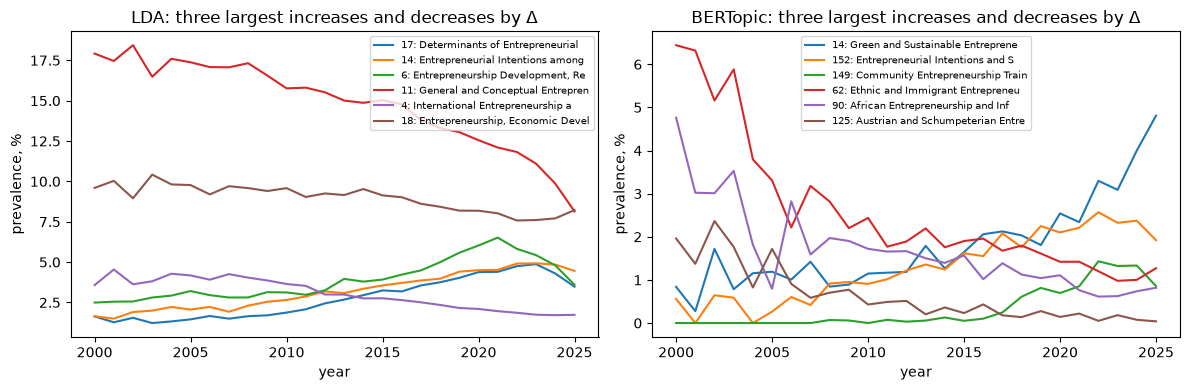

*Figure 6. RQ2: annual prevalence (%) of the three topics with the largest increases and the three with the largest decreases (early vs late mean, Δ in pp), per model.*

Full trend tables for all 25 + 153 topics: Appendix B.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, (model_name, trends, prevalence) in zip(axes, [("LDA", lda_trends, lda_prevalence_by_year), ("BERTopic", ber_trends, ber_prevalence_by_year)]):
    selected = list(trends.nlargest(3, "Δ, pp")["topic"]) + list(trends.nsmallest(3, "Δ, pp")["topic"])
    for topic in selected:
        series = 100 * prevalence.loc[prevalence["topic"] == topic, years].to_numpy()[0]
        axis.plot([int(year) for year in years], series, label=f"{topic}: {label_of[model_name][topic][:32]}")
    axis.set_title(f"{model_name}: three largest increases and decreases by Δ")
    axis.set_ylabel("prevalence, %")
    axis.set_xlabel("year")
    axis.legend(fontsize=7)
plt.tight_layout()
plt.show()
display(Markdown("*Figure 6. RQ2: annual prevalence (%) of the three topics with the largest increases and the three with the largest decreases (early vs late mean, Δ in pp), per model.*"))
print("Full trend tables for all 25 + 153 topics: Appendix B.")

## 7. RQ3 — Agreement between LDA and BERTopic

In [25]:
# frozen RQ3 protocol (analysis_config.py) and the frozen thresholds (p05_rq3_summary.json)
rq3_summary = load_json(DERIVED_DIR / "p05_rq3_summary.json")
medoid_results = rq3_summary["medoid"]
rq3_protocol = {
    "word lens": f"extrapolated RBO, p = {config.RQ3_RBO_P}, depth {config.RQ3_RBO_DEPTH}, canonical top-50 terms",
    "document lens": "cosine between LDA θ and BERTopic soft membership over shared documents",
    "one-to-one matching": "Hungarian algorithm on each lens; P = sum matched similarity / max(K_LDA, K_BERTopic)",
    "permutation null": f"{rq3_summary['n_null']} matching-aware permutations, threshold = {rq3_summary['tau_pctl']}th percentile, seed {rq3_summary['null_seed']}",
    "τ_word / τ_doc (frozen)": (round(medoid_results["tau_word"], 4), round(medoid_results["tau_doc"], 4)),
    "strong edge": "S_word ≥ τ_word and S_doc ≥ τ_doc; split = LDA topic with ≥ 2 strong edges; merge = BERTopic topic with ≥ 2 strong edges",
    "hard-assignment agreement": "AMI, ARI on BERTopic non-outlier documents (primary); sensitivity keeps −1 as a class",
    "models compared": f"LDA K = {rq3_summary['lda_K']} (medoid seed {rq3_summary['lda_medoid']}) × BERTopic {rq3_summary['ber_K_medoid']} topics (medoid seed {rq3_summary['ber_medoid']}); 100 seed pairs",
}
for key, value in rq3_protocol.items():
    print(f"{key:28s} {value}")
assert config.RQ3_N_NULL == rq3_summary["n_null"] and config.RQ3_TAU_PCTL == rq3_summary["tau_pctl"]

if RUN_HEAVY:
    # actual p05: θ inference for 10 LDA seeds, soft/hard refits for 10 BERTopic seeds, 100 pair comparisons, permutation null (hours)
    subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p05_rq3_matching.py"], check=True)

# the implementation: RBO, Hungarian sum, word/document similarity, null thresholds and strong edges
show_source(SCRIPTS_DIR / "rq3_rbo.py", ["rbo_ext"])
show_source(SCRIPTS_DIR / "p05_rq3_matching.py", ["hung_sum", "rbo_matrix_ids", "S_word", "col_norm", "edge"])
show_excerpt(SCRIPTS_DIR / "p05_rq3_matching.py", "# word-null:", "# Jaccard@50")

word lens                    extrapolated RBO, p = 0.9, depth 50, canonical top-50 terms
document lens                cosine between LDA θ and BERTopic soft membership over shared documents
one-to-one matching          Hungarian algorithm on each lens; P = sum matched similarity / max(K_LDA, K_BERTopic)
permutation null             1000 matching-aware permutations, threshold = 95th percentile, seed 20260923
τ_word / τ_doc (frozen)      (0.0204, 0.1177)
strong edge                  S_word ≥ τ_word and S_doc ≥ τ_doc; split = LDA topic with ≥ 2 strong edges; merge = BERTopic topic with ≥ 2 strong edges
hard-assignment agreement    AMI, ARI on BERTopic non-outlier documents (primary); sensitivity keeps −1 as a class
models compared              LDA K = 25 (medoid seed 2) × BERTopic 153 topics (medoid seed 4); 100 seed pairs
# ---- rq3_rbo.py: rbo_ext ----
def rbo_ext(S: Sequence[Hashable], T: Sequence[Hashable],
            p: float = 0.9, depth: int | None = None) -> float:
    """
    Ex

In [26]:
# robustness over 100 seed pairs, recomputed from p05_rq3_runpairs.csv and p05_rq3_coverage.csv and checked against the summary
seed_pair_results = read_csv(DERIVED_DIR / "p05_rq3_runpairs.csv")
coverage = read_csv(DERIVED_DIR / "p05_rq3_coverage.csv")
assert len(seed_pair_results) == 100 and len(coverage) == 10


def median_iqr_series(values, digits=4):
    q1, median, q3 = np.quantile(values, [0.25, 0.5, 0.75])
    return f"{median:.{digits}f} [{q1:.{digits}f}–{q3:.{digits}f}]", (q1, median, q3)


rows = []
for column, label in [("P_word", "P_word (RBO, Hungarian)"), ("P_doc", "P_doc (soft-membership cosine, Hungarian)"),
                      ("AMI", "AMI, primary (BERTopic non-outlier documents)"), ("ARI", "ARI, primary"),
                      ("AMI_sens", "AMI, sensitivity (−1 kept as a class)"), ("ARI_sens", "ARI, sensitivity")]:
    text, (q1, median, q3) = median_iqr_series(seed_pair_results[column])
    stored = rq3_summary["over_100_pairs"][column]
    assert np.allclose([q1, median, q3], [stored["q1"], stored["median"], stored["q3"]], atol=1e-9)
    rows.append({"statistic": label, "runs": "100 LDA × BERTopic seed pairs", "median [Q1–Q3]": text})
text, (q1, median, q3) = median_iqr_series(coverage["coverage"])
stored = rq3_summary["coverage_over_10_ber"]
assert np.allclose([q1, median, q3], [stored["q1"], stored["median"], stored["q3"]], atol=1e-9)
rows.append({"statistic": "BERTopic non-outlier coverage (share of documents)", "runs": "10 BERTopic seeds", "median [Q1–Q3]": text})
display(pd.DataFrame(rows).set_index("statistic"))

,runs,median [Q1–Q3]
statistic,,
"P_word (RBO, Hungarian)",100 LDA × BERTopic seed pairs,0.0542 [0.0521–0.0563]
"P_doc (soft-membership cosine, Hungarian)",100 LDA × BERTopic seed pairs,0.0422 [0.0411–0.0434]
"AMI, primary (BERTopic non-outlier documents)",100 LDA × BERTopic seed pairs,0.2501 [0.2445–0.2570]
"ARI, primary",100 LDA × BERTopic seed pairs,0.0494 [0.0430–0.0568]
"AMI, sensitivity (−1 kept as a class)",100 LDA × BERTopic seed pairs,0.1789 [0.1727–0.1830]
"ARI, sensitivity",100 LDA × BERTopic seed pairs,0.0094 [0.0065–0.0128]
BERTopic non-outlier coverage (share of documents),10 BERTopic seeds,0.5853 [0.5788–0.5970]


,medoid pair
statistic,
P_word,0.0522
P_doc,0.0426
τ_word,0.0204
τ_doc,0.1177
strong edges,203
LDA topics with ≥ 1 strong edge,25/25
BERTopic topics with ≥ 1 strong edge,128/153
splits (LDA topic with ≥ 2 strong edges),25
merges (BERTopic topic with ≥ 2 strong edges),59



Strongest crosswalk edges (top 15 by word similarity):


,LDA,ber_l,BERTopic,S_word,S_doc
lda_k,,,,,
3,Innovation and Entrepreneurship Education Reform in China,143,Pedagogy and Experiential Learning in Entrepreneurship Education,0.548,0.179
15,Women's Entrepreneurship and Empowerment in India,34,Women's Entrepreneurship in Africa,0.532,0.258
21,Values and Social Mission in Social Entrepreneurship,72,Social Entrepreneurship and Social Enterprises,0.510,0.358
14,Entrepreneurial Intentions among University Students,152,Entrepreneurial Intentions and Self-Efficacy,0.509,0.377
15,Women's Entrepreneurship and Empowerment in India,32,Digitalization and Women's Entrepreneurship,0.504,0.210
21,Values and Social Mission in Social Entrepreneurship,71,Social Entrepreneurship in India,0.500,0.218
15,Women's Entrepreneurship and Empowerment in India,42,Women's Entrepreneurship in India,0.500,0.343
15,Women's Entrepreneurship and Empowerment in India,39,Gender and Entrepreneurship,0.471,0.290
23,Youth Employment and Skills Development,127,Youth Entrepreneurship and Employment in Africa,0.450,0.208


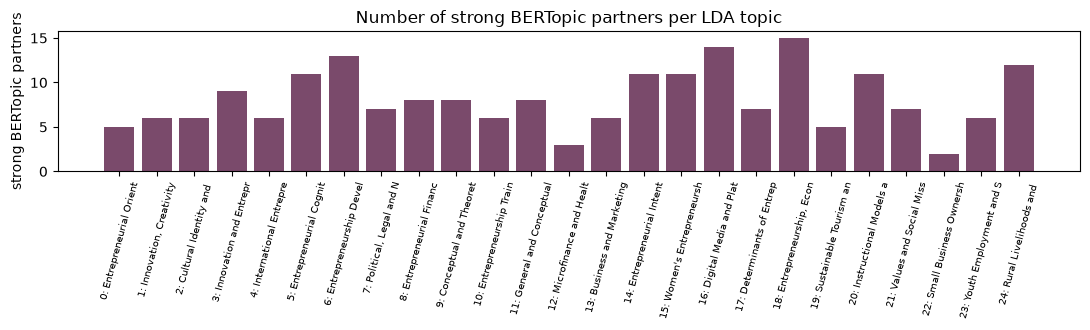

*Figure 7. RQ3: number of strong BERTopic partners (edges above both permutation thresholds) per LDA topic in the medoid pair.*

Under the fixed operational definition (≥ 2 strong edges) all 25 LDA topics are classified as splits; 59 BERTopic topics merge two or more LDA topics.


In [27]:
# medoid pair (LDA seed 2 × BERTopic seed 4): Hungarian P recomputed from the stored matchings, crosswalk recomputed from the stored strong edges
word_matching = read_csv(DERIVED_DIR / "p05_rq3_word_matching.csv")
doc_matching = read_csv(DERIVED_DIR / "p05_rq3_doc_matching.csv")
strong_edges = read_csv(DERIVED_DIR / "p05_rq3_strong_edges.csv")
k_lda, k_ber = rq3_summary["lda_K"], rq3_summary["ber_K_medoid"]

p_word = word_matching["S_word"].sum() / max(k_lda, k_ber)
p_doc = doc_matching["S_doc"].sum() / max(k_lda, k_ber)
assert len(word_matching) == len(doc_matching) == min(k_lda, k_ber)
assert np.isclose(p_word, medoid_results["P_word"]) and np.isclose(p_doc, medoid_results["P_doc"])

partner_counts = strong_edges.groupby("lda_k").size().reindex(range(k_lda), fill_value=0)
bertopic_degree = strong_edges.groupby("ber_l").size()
splits = sorted(partner_counts[partner_counts >= 2].index)
merges = sorted(bertopic_degree[bertopic_degree >= 2].index)
assert (strong_edges["S_word"] >= medoid_results["tau_word"]).all() and (strong_edges["S_doc"] >= medoid_results["tau_doc"]).all()
assert len(strong_edges) == medoid_results["n_strong_edges"] == 203
assert int((partner_counts >= 1).sum()) == medoid_results["n_lda_with_strong"] == 25
assert len(bertopic_degree) == medoid_results["n_ber_with_strong"] == 128
assert splits == medoid_results["splits_lda"] and merges == medoid_results["merges_ber"]

medoid_table = pd.DataFrame({
    "statistic": ["P_word", "P_doc", "τ_word", "τ_doc", "strong edges", "LDA topics with ≥ 1 strong edge", "BERTopic topics with ≥ 1 strong edge",
                  "splits (LDA topic with ≥ 2 strong edges)", "merges (BERTopic topic with ≥ 2 strong edges)"],
    "medoid pair": [round(p_word, 4), round(p_doc, 4), round(medoid_results["tau_word"], 4), round(medoid_results["tau_doc"], 4),
                    len(strong_edges), f"{int((partner_counts >= 1).sum())}/{k_lda}", f"{len(bertopic_degree)}/{k_ber}", len(splits), len(merges)],
}).set_index("statistic")
display(medoid_table)

strong_edges["LDA"] = [label_of["LDA"][topic] for topic in strong_edges["lda_k"]]
strong_edges["BERTopic"] = [label_of["BERTopic"][topic] for topic in strong_edges["ber_l"]]
print("\nStrongest crosswalk edges (top 15 by word similarity):")
display(strong_edges.sort_values("S_word", ascending=False).head(15)[["lda_k", "LDA", "ber_l", "BERTopic", "S_word", "S_doc"]].round(3).set_index("lda_k"))

fig, axis = plt.subplots(figsize=(11, 3.4))
bar_labels = [f"{topic}: {label_of['LDA'][topic][:22]}" for topic in partner_counts.index]
axis.bar(bar_labels, partner_counts.values, color="#7A4A6B")
axis.set_ylabel("strong BERTopic partners")
axis.set_title("Number of strong BERTopic partners per LDA topic")
plt.xticks(rotation=75, fontsize=7)
plt.tight_layout()
plt.show()
display(Markdown("*Figure 7. RQ3: number of strong BERTopic partners (edges above both permutation thresholds) per LDA topic in the medoid pair.*"))
print(f"Under the fixed operational definition (≥ 2 strong edges) all {len(splits)} LDA topics are classified as splits; "
      f"{len(merges)} BERTopic topics merge two or more LDA topics.")

## 8. RQ4 — Sensitivity to the corpus definition

In [28]:
# frozen RQ4 protocol (rq4_protocol_FROZEN.json)
rq4_protocol = load_json(DERIVED_DIR / "rq4_protocol_FROZEN.json")
for key in list(rq4_protocol)[:12]:
    print(f"{key:28s} {str(rq4_protocol[key])[:150]}")

if RUN_HEAVY:
    # actual RQ4 re-fits (many hours): subset LDA (p07), subset BERTopic (p08), cross-corpus comparison (p09)
    for subset in ["soft", "strict"]:
        for stage in ["preprocess", "ksearch", "select", "final"]:
            subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p07_subset_lda.py", "--subset", subset, "--stage", stage], check=True)
        for stage in ["embeddings", "cluster_search", "cluster_metrics", "select", "final"]:
            subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p08_subset_bertopic.py", "--subset", subset, "--stage", stage], check=True)
        for method in ["lda", "ber"]:
            subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p09_rq4_compare.py", "--method", method, "--subset", subset], check=True)

# the implementation of the cross-corpus comparison (printed from the module itself)
show_source(SCRIPTS_DIR / "p09_rq4_compare.py", ["lda_data", "compare_lda", "ber_data", "compare_ber", "_cosmat", "run"])

component                    RQ4 protocol
status                       FROZEN (design)
confirmed_by_user            True
date                         2026-09-23
training                     full independent retrain SOFT(89249)/STRICT(43519): own phraser(20/.35/npmi)+dict(min_df20,max_df.5,NOUN+ADJ,stop326+dom7)+canonical ref; LDA same K-g
comparison                   medoid-only, within-method, 4 pairs (MAIN↔SOFT, MAIN↔STRICT for LDA & BERTopic). S_word=RBO_ext(.9,50); S_doc=cosine doc-support (LDA: subset∩usable_M
NO                           null/τ_word/τ_doc/strong-edge graph/auto split-merge counting/word-null union vocab/seed-wise 100-pair cross-corpus. splits/merges interpreted AFTER l
diagnostics                  per solution: sizes, K/mcs, n_topics, LDA stability, BER stability, BER outlier share, NPMI/Cv/diversity descriptive (NO cross-corpus quality ranking)
prevalence                   matched pair: LDA mean θ_k in corpus; BER hard count/all docs (P06 logic); Δpp=100(p_subse

In [29]:
# per-solution quality: MAIN (p03/p04) and the four re-fits (rq4/{soft,strict}/{lda,bert}); median over 10 seeds, medoid values separately


def metrics_of(summary):
    return summary.get("metrics_over_10") or summary.get("metrics_over_10_runs")


def stability_of(summary):
    return (summary.get("stability_over_45") or summary.get("stability_over_45_pairs"))["median"]


corpus_sizes = {"MAIN": 106524, "SOFT": 89249, "STRICT": 43519}
solution_rows = []
for corpus, n_documents_corpus in corpus_sizes.items():
    if corpus == "MAIN":
        lda_selection_c = load_json(DERIVED_DIR / "p03_select.json")
        lda_summary_c = load_json(DERIVED_DIR / "p03_final_summary.json")
        bertopic_summary_c = load_json(DERIVED_DIR / "p04_final_summary.json")
    else:
        subset_dir = DERIVED_DIR / "rq4" / corpus.lower()
        lda_selection_c = load_json(subset_dir / "lda" / "select.json")
        lda_summary_c = load_json(subset_dir / "lda" / "final_summary.json")
        bertopic_summary_c = load_json(subset_dir / "bert" / "final_summary.json")
    lda_metrics = metrics_of(lda_summary_c)
    solution_rows.append({"model": "LDA", "corpus": corpus, "N": n_documents_corpus, "K / topics (medoid)": lda_selection_c["selected_K"],
                          "NPMI@20": lda_metrics["NPMI"]["median"], "C_v": lda_metrics["C_v"]["median"], "diversity": lda_metrics["diversity"]["median"],
                          "stability P": stability_of(lda_summary_c), "outlier, median over 10 seeds": None, "outlier, medoid": None})
    bertopic_metrics = metrics_of(bertopic_summary_c)
    solution_rows.append({"model": "BERTopic", "corpus": corpus, "N": n_documents_corpus, "K / topics (medoid)": bertopic_summary_c["n_nonoutlier_clusters"],
                          "NPMI@20": bertopic_metrics["NPMI"]["median"], "C_v": bertopic_metrics["C_v"]["median"], "diversity": bertopic_metrics["diversity"]["median"],
                          "stability P": stability_of(bertopic_summary_c), "outlier, median over 10 seeds": bertopic_metrics["outlier_share"]["median"],
                          "outlier, medoid": bertopic_summary_c["medoid_outlier_share"]})
solution_table = pd.DataFrame(solution_rows).set_index(["model", "corpus"]).round(4)
print("Per-solution quality (median over 10 seeds). Absolute coherence is not comparable across corpora (each corpus has its own reference corpus).")
display(solution_table)

Per-solution quality (median over 10 seeds). Absolute coherence is not comparable across corpora (each corpus has its own reference corpus).


,,N,K / topics (medoid),NPMI@20,C_v,diversity,stability P,"outlier, median over 10 seeds","outlier, medoid"
model,corpus,,,,,,,,
LDA,MAIN,106524,25,0.0496,0.5174,0.7360,0.6232,NaN,NaN
BERTopic,MAIN,106524,153,0.0760,0.5687,0.4759,0.8642,0.4146,0.4341
LDA,SOFT,89249,20,0.0471,0.5123,0.7080,0.6288,NaN,NaN
BERTopic,SOFT,89249,77,0.0731,0.5626,0.4937,0.8709,0.3902,0.4064
LDA,STRICT,43519,10,0.0344,0.4811,0.7480,0.6732,NaN,NaN
BERTopic,STRICT,43519,72,0.0640,0.5307,0.4862,0.7878,0.3414,0.3652


In [30]:
# cross-corpus correspondence recomputed from the stored Hungarian matchings (rq4/compare/p09_*_{word,doc}.csv) and checked against the summaries
comparison_rows = []
distribution_rows = []
for method, model_name in [("lda", "LDA"), ("ber", "BERTopic")]:
    for subset in ["soft", "strict"]:
        summary = load_json(DERIVED_DIR / "rq4" / "compare" / f"p09_{method}_{subset}_summary.json")
        word_pairs = read_csv(DERIVED_DIR / "rq4" / "compare" / f"p09_{method}_{subset}_word.csv")
        doc_pairs = read_csv(DERIVED_DIR / "rq4" / "compare" / f"p09_{method}_{subset}_doc.csv")
        k_main, k_subset = summary["K_main"], summary["K_sub"]
        n_matched = min(k_main, k_subset)
        assert len(word_pairs) == len(doc_pairs) == n_matched
        p_word_pair = word_pairs["RBO"].sum() / max(k_main, k_subset)
        p_doc_pair = doc_pairs["doc_cos"].sum() / max(k_main, k_subset)
        mean_matched_rbo = word_pairs["RBO"].mean()
        mean_matched_doccos = doc_pairs["doc_cos"].mean()
        max_possible = n_matched / max(k_main, k_subset)
        assert np.isclose(p_word_pair / max_possible, mean_matched_rbo) and np.isclose(p_doc_pair / max_possible, mean_matched_doccos)
        assert np.isclose(p_word_pair, summary["P_word"], atol=1e-3) and np.isclose(p_doc_pair, summary["P_doc"], atol=1e-3)
        word_partners = set(zip(word_pairs["main_topic"], word_pairs["sub_topic"]))
        doc_partners = set(zip(doc_pairs["main_topic"], doc_pairs["sub_topic"]))
        comparison_rows.append({"model": model_name, "pair": f"MAIN ↔ {subset.upper()}", "K": f"{k_main} ↔ {k_subset}", "matched": n_matched,
                                "P_word": round(p_word_pair, 4), "P_doc": round(p_doc_pair, 4), "max possible P": round(max_possible, 4),
                                "mean matched RBO": round(mean_matched_rbo, 4), "mean matched doc-cosine": round(mean_matched_doccos, 4),
                                "shared documents": summary["n_shared_docs"]})
        rbo_q = np.quantile(word_pairs["RBO"], [0.25, 0.5, 0.75])
        doc_q = np.quantile(doc_pairs["doc_cos"], [0.25, 0.5, 0.75])
        distribution_rows.append({"model": model_name, "pair": f"MAIN ↔ {subset.upper()}",
                                  "matched RBO: median [Q1–Q3], min": f"{rbo_q[1]:.3f} [{rbo_q[0]:.3f}–{rbo_q[2]:.3f}], {word_pairs['RBO'].min():.3f}",
                                  "matched doc-cosine: median [Q1–Q3], min": f"{doc_q[1]:.3f} [{doc_q[0]:.3f}–{doc_q[2]:.3f}], {doc_pairs['doc_cos'].min():.3f}",
                                  "same partner in both lenses": f"{len(word_partners & doc_partners)}/{n_matched}"})
print("Cross-corpus correspondence (medoid ↔ medoid, within method); P / (min K / max K) equals the mean matched similarity by construction (asserted):")
display(pd.DataFrame(comparison_rows).set_index(["model", "pair"]))
print("\nDistribution of matched similarities (word-lens pairs and document-lens pairs are two separate Hungarian matchings):")
display(pd.DataFrame(distribution_rows).set_index(["model", "pair"]))

Cross-corpus correspondence (medoid ↔ medoid, within method); P / (min K / max K) equals the mean matched similarity by construction (asserted):


K  matched  P_word   P_doc  max possible P  mean matched RBO  mean matched doc-cosine  shared documents
model    pair                                                                                                                         
LDA      MAIN ↔ SOFT     25 ↔ 20       20  0.4436  0.6035          0.8000            0.5544                   0.7544             89225
         MAIN ↔ STRICT   25 ↔ 10       10  0.1979  0.3008          0.4000            0.4946                   0.7519             43512
BERTopic MAIN ↔ SOFT    153 ↔ 77       77  0.4008  0.3873          0.5033            0.7964                   0.7695             89249
         MAIN ↔ STRICT  153 ↔ 72       72  0.3356  0.3313          0.4706            0.7132                   0.7040             43519


Distribution of matched similarities (word-lens pairs and document-lens pairs are two separate Hungarian matchings):


matched RBO: median [Q1–Q3], min matched doc-cosine: median [Q1–Q3], min same partner in both lenses
model    pair                                                                                                              
LDA      MAIN ↔ SOFT         0.568 [0.429–0.681], 0.168              0.773 [0.698–0.834], 0.457                       16/20
         MAIN ↔ STRICT       0.455 [0.417–0.574], 0.349              0.791 [0.681–0.813], 0.587                        6/10
BERTopic MAIN ↔ SOFT         0.846 [0.756–0.895], 0.431              0.804 [0.736–0.837], 0.475                       75/77
         MAIN ↔ STRICT       0.743 [0.664–0.825], 0.178              0.769 [0.646–0.846], 0.082                       60/72

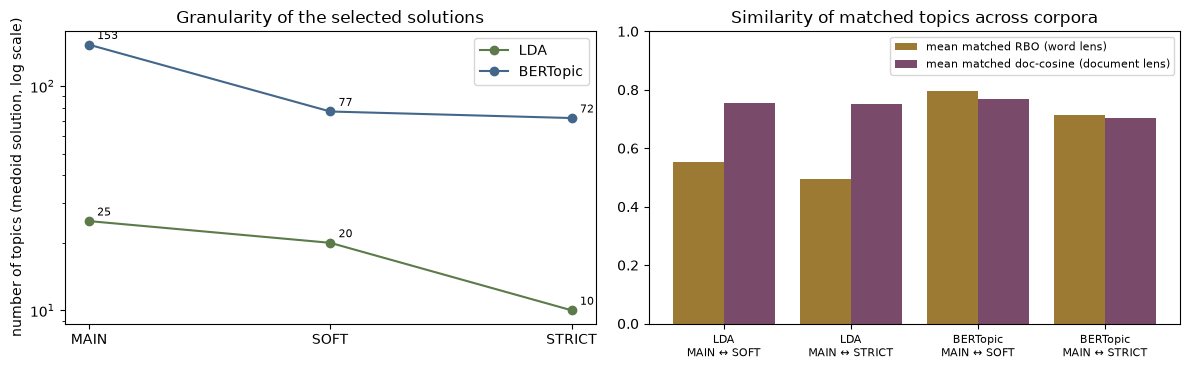

*Figure 8. RQ4: number of topics in the selected solutions on MAIN / SOFT / STRICT (left, log scale) and mean matched similarity between MAIN and each subset under the word and document lenses (right).*

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
granularity = solution_table.reset_index()
for model_name, color in [("LDA", "#5C7A4A"), ("BERTopic", "#43678A")]:
    values = granularity[granularity["model"] == model_name].set_index("corpus").loc[["MAIN", "SOFT", "STRICT"], "K / topics (medoid)"]
    axes[0].plot(["MAIN", "SOFT", "STRICT"], values.values, "o-", color=color, label=model_name)
    for corpus, value in values.items():
        axes[0].annotate(str(int(value)), (corpus, value), textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[0].set_yscale("log")
axes[0].set_ylabel("number of topics (medoid solution, log scale)")
axes[0].set_title("Granularity of the selected solutions")
axes[0].legend()
comparison = pd.DataFrame(comparison_rows)
positions = np.arange(len(comparison))
axes[1].bar(positions - 0.2, comparison["mean matched RBO"], width=0.4, color="#9C7A33", label="mean matched RBO (word lens)")
axes[1].bar(positions + 0.2, comparison["mean matched doc-cosine"], width=0.4, color="#7A4A6B", label="mean matched doc-cosine (document lens)")
axes[1].set_xticks(positions)
axes[1].set_xticklabels([f"{row.model}\n{row.pair}" for row in comparison.itertuples()], fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_title("Similarity of matched topics across corpora")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
display(Markdown("*Figure 8. RQ4: number of topics in the selected solutions on MAIN / SOFT / STRICT (left, log scale) and mean matched similarity between MAIN and each subset under the word and document lenses (right).*"))

## 9. RQ5 — Correspondence with previous maps of the field

In [32]:
# RQ5 inputs (rq5/): reference table, coding links, screening log, frozen protocol and results
RQ5_DIR = DERIVED_DIR / "rq5"
reference_units = read_csv(RQ5_DIR / "rq5_reference_table.csv")
coding_links = read_csv(RQ5_DIR / "packet" / "rq5_coding_links.csv")
screening_log = read_csv(RQ5_DIR / "packet" / "rq5_screening_log.csv")
frozen_rq5 = load_json(RQ5_DIR / "RQ5_FROZEN.json")
rq5_protocol = load_json(RQ5_DIR / "RQ5_R3_PROTOCOL_FROZEN.json")
source_names = {"Chandra 2018": "Chandra 2018",
                "Cabeza Ramírez, Sánchez-Cañizares & Fuentes-García 2019": "Cabeza Ramírez et al. 2019",
                "García-Lillo, Seva-Larrosa & Sánchez-García 2023": "García-Lillo et al. 2023"}
sources = list(source_names)

print("Reference units by source:", reference_units.groupby("source").size().to_dict())
assert len(reference_units) == 69 and (reference_units["verified"] == True).all()
print("Codes in the frozen protocol (defined above):", ", ".join(rq5_protocol["codes_our_to_reference"]))

n_direct = int((coding_links["code"] == "direct").sum())
n_partial = int((coding_links["code"] == "partial").sum())
n_review = int((coding_links["code"] == "review").sum())
assert len(screening_log) == 138 and (screening_log["screened"] == True).all()
assert len(coding_links) == 327 and n_direct == 34 and n_partial == 293 and n_review == 0
print(f"\nScreenings logged: {len(screening_log)}/138 | positive links: {len(coding_links)} (direct {n_direct}, partial {n_partial}, review {n_review})")

if RUN_HEAVY:
    # p11 rebuilds and audits the reference table from the full texts (deterministic); p12 (coding packet) is NOT re-run:
    # the frozen human-coding files (rq5_coding_links.csv, rq5_screening_log.csv) must not be regenerated
    subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p11_rq5_reference_table.py"], check=True)
    subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p11_reference_audit.py"], check=True)

# the implementation: reference-table checks, packet construction (shown, not re-run), mechanical derivation, embedding diagnostic
show_source(SCRIPTS_DIR / "p11_reference_audit.py", ["norm", "pages"])
show_source(SCRIPTS_DIR / "p12_rq5_packet.py", ["sections", "card"])
show_source(SCRIPTS_DIR / "p13_rq5_tally.py", ["final"])

Reference units by source: {'Cabeza Ramírez, Sánchez-Cañizares & Fuentes-García 2019': 7, 'Chandra 2018': 46, 'García-Lillo, Seva-Larrosa & Sánchez-García 2023': 16}
Codes in the frozen protocol (defined above): direct, partial, no_reference_match, review

Screenings logged: 138/138 | positive links: 327 (direct 34, partial 293, review 0)
# ---- p11_reference_audit.py: norm ----
def norm(s):
    s = re.sub("­\\s*", "", s)   # мягкий перенос + перевод строки внутри слова (Elsevier: "pa\xad\npers" → "papers")
    # Sk-глифы (´ U+00B4, ¨ U+00A8 …) снимаем ДО NFKD: NFKD раскладывает их в "пробел + combining" и оставил бы пробел
    s = "".join(c for c in s if unicodedata.category(c) not in ("Sk", "Lm"))
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.category(c).startswith("M"))   # combining-акценты
    s = s.replace("’", "'").replace("‘", "'").replace("ﬁ", "fi").replace("ﬂ", "fl")
    s = re.sub(r"-\s+", "-", s)            # переносы "spin- off" →

In [33]:
# mechanical derivation (p13) repeated in the notebook from the stored links and checked against the stored tally
frozen_reference_to_ours = read_csv(RQ5_DIR / "rq5_reference_to_ours.csv")
frozen_coverage = load_json(RQ5_DIR / "rq5_coverage_by_source.json")
source_keys = {"Chandra 2018": "chandra", "Cabeza Ramírez, Sánchez-Cañizares & Fuentes-García 2019": "cabeza", "García-Lillo, Seva-Larrosa & Sánchez-García 2023": "gl"}
frozen_pass_keys = {"Chandra 2018": "Chandra", "Cabeza Ramírez, Sánchez-Cañizares & Fuentes-García 2019": "Cabeza", "García-Lillo, Seva-Larrosa & Sánchez-García 2023": "García-Lillo"}
topics_per_model = {"LDA": 25, "BERTopic": 153}

pass_rows = []
reference_rows = []
for model in ["LDA", "BERTopic"]:
    for source in sources:
        units = reference_units.loc[reference_units["source"] == source, "reference_id"].tolist()
        links = coding_links[(coding_links["model"] == model) & (coding_links["source"] == source)]
        links_per_unit = links.groupby("reference_id").size()
        links_per_topic = links.groupby("our_topic_id").size()
        for unit in units:
            unit_links = links[links["reference_id"] == unit]
            if len(unit_links) == 0:
                code_ref_to_ours = "no_identified_counterpart"
            elif len(unit_links) >= 2:
                code_ref_to_ours = "split"
            elif unit_links["code"].iloc[0] == "direct":
                code_ref_to_ours = "present-direct"
            else:
                code_ref_to_ours = "present-partial"
            reference_rows.append({"model": model, "source": source_names[source], "reference_id": unit, "code_ref_to_ours": code_ref_to_ours})
        topics_with_link = int(links_per_topic.size)
        pass_rows.append({"model": model, "source": source_names[source], "links": len(links),
                          "direct": int((links["code"] == "direct").sum()), "partial": int((links["code"] == "partial").sum()),
                          "units with ≥ 1 counterpart": f"{int(links_per_unit.size)}/{len(units)}",
                          "topics with ≥ 1 link": f"{topics_with_link}/{topics_per_model[model]}",
                          "no reference match (topics)": f"{topics_per_model[model] - topics_with_link}/{topics_per_model[model]}",
                          "topics linked to ≥ 2 units (merge)": int((links_per_topic >= 2).sum())})
        # checks against the stored tally
        frozen_pass = frozen_rq5["by_pass"][f"{model} × {frozen_pass_keys[source]}"]
        assert len(links) == frozen_pass["links"] and pass_rows[-1]["units with ≥ 1 counterpart"] == frozen_pass["units_with_counterpart"]
        assert pass_rows[-1]["topics with ≥ 1 link"] == frozen_pass["topics_with_link"]
        assert pass_rows[-1]["direct"] == frozen_pass["direct"] and pass_rows[-1]["partial"] == frozen_pass["partial"]
        assert pass_rows[-1]["no reference match (topics)"] == frozen_rq5["no_reference_match_topics"][model][frozen_pass_keys[source]]
        frozen_cov = frozen_coverage[f"{model} × {source_keys[source]}"]
        assert pass_rows[-1]["topics linked to ≥ 2 units (merge)"] == frozen_cov["merges(topics with ≥2 units)"]

reference_to_ours = pd.DataFrame(reference_rows)
merged = reference_to_ours.merge(frozen_reference_to_ours.assign(source=lambda d: d["source"].map(source_names)), on=["model", "source", "reference_id"], suffixes=("", "_frozen"))
assert len(merged) == 138 and (merged["code_ref_to_ours"] == merged["code_ref_to_ours_frozen"]).all()
print("Mechanical derivation recomputed from the stored links matches the stored tally (6 passes, 138 reference → ours codes).")

pass_table = pd.DataFrame(pass_rows).set_index(["model", "source"])
print("\nCoverage — reported per source (the three sets differ in level and size):")
display(pass_table)
code_distribution = reference_to_ours.groupby(["source", "model", "code_ref_to_ours"]).size().unstack(fill_value=0)
code_distribution = code_distribution.reindex(columns=["present-direct", "present-partial", "split", "no_identified_counterpart"], fill_value=0)
print("\nReference → our topics (mechanical from the human links):")
display(code_distribution)

Mechanical derivation recomputed from the stored links matches the stored tally (6 passes, 138 reference → ours codes).

Coverage — reported per source (the three sets differ in level and size):


links  direct  partial units with ≥ 1 counterpart topics with ≥ 1 link no reference match (topics)  \
model    source                                                                                                                           
LDA      Chandra 2018                   50       6       44                      34/46                21/25                        4/25   
         Cabeza Ramírez et al. 2019     17       0       17                        7/7                 9/25                       16/25   
         García-Lillo et al. 2023       20       2       18                      16/16                13/25                       12/25   
BERTopic Chandra 2018                  156      22      134                      39/46              115/153                      38/153   
         Cabeza Ramírez et al. 2019     53       0       53                        7/7               30/153                     123/153   
         García-Lillo et al. 2023       31       4       27                      15/16               28/153                     125/153   

                                     topics linked to ≥ 2 units (merge)  
model    source                                                          
LDA      Chandra 2018                                                12  
         Cabeza Ramírez et al. 2019                                   4  
         García-Lillo et al. 2023                                     6  
BERTopic Chandra 2018                                                35  
         Cabeza Ramírez et al. 2019                                   9  
         García-Lillo et al. 2023                                     3


Reference → our topics (mechanical from the human links):


code_ref_to_ours                     present-direct  present-partial  split  no_identified_counterpart
source                     model                                                                      
Cabeza Ramírez et al. 2019 BERTopic               0                0      7                          0
                           LDA                    0                1      6                          0
Chandra 2018               BERTopic               8                4     27                          7
                           LDA                    3               22      9                         12
García-Lillo et al. 2023   BERTopic               1                4     10                          1
                           LDA                    2               10      4                          0

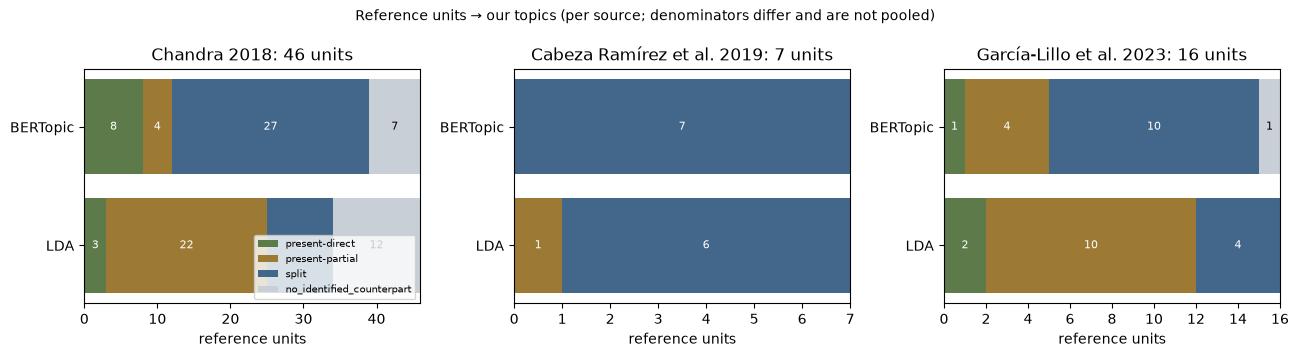

*Figure 9. RQ5: mechanical classification of the reference units of each source by their counterparts in our topics (present-direct / present-partial / split / no identified counterpart), per model; denominators differ by source and are not pooled.*

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=False)
colors = {"present-direct": "#5C7A4A", "present-partial": "#9C7A33", "split": "#43678A", "no_identified_counterpart": "#C9CFD6"}
for axis, source in zip(axes, sources):
    short = source_names[source]
    n_units = int((reference_units["source"] == source).sum())
    for row_index, model in enumerate(["LDA", "BERTopic"]):
        counts = code_distribution.loc[(short, model)]
        left = 0
        for code_name in ["present-direct", "present-partial", "split", "no_identified_counterpart"]:
            value = int(counts[code_name])
            axis.barh(model, value, left=left, color=colors[code_name], label=code_name if (axis is axes[0] and row_index == 0) else None)
            if value > 0:
                axis.text(left + value / 2, row_index, str(value), ha="center", va="center", fontsize=8, color="white" if code_name != "no_identified_counterpart" else "black")
            left += value
    axis.set_xlim(0, n_units)
    axis.set_title(f"{short}: {n_units} units")
    axis.set_xlabel("reference units")
axes[0].legend(fontsize=7, loc="lower right")
plt.suptitle("Reference units → our topics (per source; denominators differ and are not pooled)", fontsize=10)
plt.tight_layout()
plt.show()
display(Markdown("*Figure 9. RQ5: mechanical classification of the reference units of each source by their counterparts in our topics (present-direct / present-partial / split / no identified counterpart), per model; denominators differ by source and are not pooled.*"))

In [35]:
# direct correspondences, units without counterpart, and the post-hoc embedding diagnostic
direct_links = coding_links[coding_links["code"] == "direct"].copy()
direct_links["source"] = direct_links["source"].map(source_names)
unit_label = dict(zip(reference_units["reference_id"], reference_units["exact_label"]))
direct_links["reference unit"] = [unit_label[unit] for unit in direct_links["reference_id"]]
direct_links["our topic"] = [f"{model} {topic}: {label_of[model][topic]}" for model, topic in zip(direct_links["model"], direct_links["our_topic_id"])]
print("All direct correspondences:")
display(direct_links.sort_values(["model", "reference_id"])[["model", "source", "reference_id", "reference unit", "our topic"]].set_index(["model", "source"]))

without = frozen_rq5["units_without_counterpart"]
print("\nReference units without counterpart in BOTH models:", "; ".join(without["in_both_models"]))
print("Without counterpart only in BERTopic:", "; ".join(without["only_BERTopic"]))

embedding_diagnostic_protocol = {
    "timing": "after all human codes were frozen (138/138 screenings, review = 0)",
    "reference text": "exact_label + anchor_terms (authors' words only; the Russian paraphrase 'definition' is not used)",
    "topic text": "final_label + description + top-15 native terms",
    "encoder": f"{config.EMBED_MODEL} @ {config.EMBED_REVISION[:12]} (pinned, local_files_only), L2-normalised",
    "statistics": "cosine for all 178 × 69 topic–unit pairs; cosine by human code (direct / partial / unlinked); rank of the coded partner among the units of its source",
    "purpose": "auxiliary agreement diagnostic; it does not alter any human code",
}
print("\nEmbedding diagnostic (R7) protocol:")
for key, value in embedding_diagnostic_protocol.items():
    print(f"  {key:16s} {value}")
# the implementation: how the two text sides are built and encoded (printed from the module itself)
show_excerpt(SCRIPTS_DIR / "p14_rq5_embed_diag.py", "# ---------- тексты", "# ---------- pairs csv")

embedding_diag = load_json(RQ5_DIR / "rq5_embed_diag.json")
print("\nPost-hoc embedding diagnostic (auxiliary):", frozen_rq5["r7_embedding_diagnostic"]["finding_exact"])
embedding_rows = []
for comparison, values in embedding_diag.items():
    if comparison.startswith("_"):
        continue
    model, source = comparison.split(" × ", 1)
    by_code = values["cosine_by_human_code"]
    rank = values["coded_partner_rank_among_units"]
    embedding_rows.append({"model": model, "source": source_names[source],
                           "median cosine · direct": by_code["direct"].get("median"), "median cosine · partial": by_code["partial"].get("median"),
                           "median cosine · unlinked": by_code["unlinked"].get("median"),
                           "coded partner: median rank / units": f"{rank['median_rank']:.0f} / {rank['n_units']}", "coded partner in top-5 by cosine": rank["share_top5"]})
display(pd.DataFrame(embedding_rows).set_index(["model", "source"]).round(3))

if RUN_HEAVY:
    # p14 re-runs the post-hoc diagnostic only once the human codes are complete and frozen
    assert (screening_log["screened"] == True).all() and n_review == 0
    subprocess.run([PIPELINE_PYTHON, SCRIPTS_DIR / "p14_rq5_embed_diag.py"], check=True)

All direct correspondences:


reference_id  \
model    source                                  
BERTopic Chandra 2018                  C18-T04   
         Chandra 2018                  C18-T07   
         Chandra 2018                  C18-T09   
         Chandra 2018                  C18-T10   
         Chandra 2018                  C18-T12   
         Chandra 2018                  C18-T13   
         Chandra 2018                  C18-T15   
         Chandra 2018                  C18-T16   
         Chandra 2018                  C18-T18   
         Chandra 2018                  C18-T19   
         Chandra 2018                  C18-T21   
         Chandra 2018                  C18-T22   
         Chandra 2018                  C18-T27   
         Chandra 2018                  C18-T29   
         Chandra 2018                  C18-T29   
         Chandra 2018                  C18-T31   
         Chandra 2018                  C18-T32   
         Chandra 2018                  C18-T33   
         Chandra 2018                  C18-T34   
         Chandra 2018                  C18-T37   
         Chandra 2018                  C18-T39   
         Chandra 2018                  C18-T42   
         García-Lillo et al. 2023     GL23-F01   
         García-Lillo et al. 2023     GL23-F03   
         García-Lillo et al. 2023     GL23-F04   
         García-Lillo et al. 2023     GL23-F10   
LDA      Chandra 2018                  C18-T01   
         Chandra 2018                  C18-T16   
         Chandra 2018                  C18-T22   
         Chandra 2018                  C18-T26   
         Chandra 2018                  C18-T31   
         Chandra 2018                  C18-T39   
         García-Lillo et al. 2023     GL23-F01   
         García-Lillo et al. 2023     GL23-F03   

                                                                                                                                            reference unit  \
model    source                                                                                                                                              
BERTopic Chandra 2018                                                                                                         innovation & tech management   
         Chandra 2018                                                                                                                             strategy   
         Chandra 2018                                                                                                                              network   
         Chandra 2018                                                                                                                              culture   
         Chandra 2018                                                                                                       institutional entrepreneurship   
         Chandra 2018                                                                                                              narrative and discourse   
         Chandra 2018                                                                                                                               ethics   
         Chandra 2018                                                                                       internationalization and intl entrepreneurship   
         Chandra 2018                                                                                                          entrepreneurial orientation   
         Chandra 2018                                                                                                                      venture capital   
         Chandra 2018                                                                                                             decision making and risk   
         Chandra 2018                                                                                                    investment, capital and financing   
         Chandra 2018


Reference units without counterpart in BOTH models: C18-T24 competition; C18-T38 capability, exploration and exploitation; C18-T41 multinational enterprises and business strategy; C18-T45 governance and board of directors; C18-T46 top management team
Without counterpart only in BERTopic: C18-T06 failure (LDA: partial via LDA22); C18-T23 human capital (LDA: partial via LDA23); GL23-F12 effectuation and causation (LDA: partial via LDA5)

Embedding diagnostic (R7) protocol:
  timing           after all human codes were frozen (138/138 screenings, review = 0)
  reference text   exact_label + anchor_terms (authors' words only; the Russian paraphrase 'definition' is not used)
  topic text       final_label + description + top-15 native terms
  encoder          all-MiniLM-L6-v2 @ 1110a243fdf4 (pinned, local_files_only), L2-normalised
  statistics       cosine for all 178 × 69 topic–unit pairs; cosine by human code (direct / partial / unlinked); rank of the coded partner among the units of it

median cosine · direct  median cosine · partial  median cosine · unlinked coded partner: median rank / units  \
model    source                                                                                                                                     
LDA      Cabeza Ramírez et al. 2019                     NaN                    0.485                     0.253                              2 / 7   
         Chandra 2018                                 0.655                    0.407                     0.238                             6 / 46   
         García-Lillo et al. 2023                     0.683                    0.531                     0.353                             2 / 16   
BERTopic Cabeza Ramírez et al. 2019                     NaN                    0.410                     0.246                              2 / 7   
         Chandra 2018                                 0.629                    0.449                     0.232                             2 / 46   
         García-Lillo et al. 2023                     0.721                    0.565                     0.359                             1 / 16   

                                     coded partner in top-5 by cosine  
model    source                                                        
LDA      Cabeza Ramírez et al. 2019                             0.882  
         Chandra 2018                                           0.480  
         García-Lillo et al. 2023                               0.800  
BERTopic Cabeza Ramírez et al. 2019                             0.925  
         Chandra 2018                                           0.603  
         García-Lillo et al. 2023                               0.935

## 10. Summary across research questions

## Appendix A — Full BERTopic topic list (153 topics, human labels)

In [36]:
with pd.option_context("display.max_rows", None):
    display(rq1_ber.set_index("topic").sort_values("size", ascending=False).round(4))

,final_label,description,size,share_pct,top_terms
topic,,,,,
14,Green and Sustainable Entrepreneurship,"Research on green and sustainable entrepreneurship, including sustainability orientation, green ventures, renewable ...",2898,2.7205,"green, sustainable, environmental, sustainability, energy, sustainable entrepreneurship, green entrepreneurship, sus..."
12,Tourism Entrepreneurship and Rural Tourism,"Research on tourism entrepreneurship and rural tourism, including agritourism, ecotourism, hospitality, and small to...",2092,1.9639,"tourism, tourist, hospitality, local, rural tourism, rural, tourism entrepreneurship, heritage"
87,Innovation and Entrepreneurship Training in Colleges and Universities,"Research on innovation and entrepreneurship training in colleges and universities, including training systems, vocat...",1918,1.8005,"innovation entrepreneurship, college, entrepreneurship education, education, colleges, innovation, vocational, talents"
152,Entrepreneurial Intentions and Self-Efficacy,"Research on entrepreneurial intentions and self-efficacy, including attitudes, perceived behavioral control, and the...",1913,1.7958,"intention, entrepreneurial intention, self-efficacy, intentions, entrepreneurial intentions, students, entrepreneurs..."
72,Social Entrepreneurship and Social Enterprises,"Research on social entrepreneurship and social enterprises, including work-integration social enterprises, social ec...",1834,1.7217,"social, social entrepreneurship, social enterprises, enterprises, social enterprise, development social, social entr..."
62,Ethnic and Immigrant Entrepreneurship,"Research on ethnic and immigrant entrepreneurship, including immigrant, minority, Black, and diaspora entrepreneurs ...",1829,1.7170,"ethnic, immigrant, black, immigrants, migration, migrant, transnational, migrants"
143,Pedagogy and Experiential Learning in Entrepreneurship Education,"Research on pedagogy and experiential learning in entrepreneurship education, including experiential pedagogies, com...",1464,1.3743,"education, entrepreneurship education, learning, teaching, educational, students, ee, teachers"
90,African Entrepreneurship and Informal Economies,"A mixed cluster on African entrepreneurship and informal economies, including the informal sector, innovation hubs, ...",1230,1.1547,"africa, african, informal, south, south africa, hubs, innovation hubs, growth"
20,Healthcare and Medical Entrepreneurship,"Research on entrepreneurship in healthcare and medicine, including medical/physician entrepreneurship, healthcare in...",1167,1.0955,"health, medical, care, clinical, healthcare, patients, medicine, health care"


## Appendix B — Full RQ2 trend tables

In [37]:
with pd.option_context("display.max_rows", None):
    print("LDA (25 topics): early/late means in %, Δ in percentage points")
    display(lda_trends.set_index("topic").round(3))
    print("BERTopic (153 topics): early/late means in %, Δ in percentage points")
    display(ber_trends.set_index("topic").round(3))

LDA (25 topics): early/late means in %, Δ in percentage points


,label,"early mean 2000–04, %","late mean 2021–25, %","Δ, pp","Theil–Sen, pp/year",Kendall τ
topic,,,,,,
0,Entrepreneurial Orientation and Organizational Performance,2.813,2.650,-0.163,-0.007,-0.169
1,"Innovation, Creativity and Entrepreneurial Leadership",1.533,1.948,0.415,0.018,0.538
2,Cultural Identity and Ethnic Entrepreneurship,4.025,2.333,-1.692,-0.079,-0.865
3,Innovation and Entrepreneurship Education Reform in China,2.123,3.809,1.686,0.075,0.360
4,International Entrepreneurship and SME Internationalization,3.968,1.803,-2.165,-0.125,-0.822
5,Entrepreneurial Cognition and Individual Differences,7.295,6.381,-0.914,-0.053,-0.563
6,"Entrepreneurship Development, Regulation and State Support",2.668,5.232,2.565,0.130,0.754
7,"Political, Legal and Norm Entrepreneurship",3.808,2.039,-1.769,-0.079,-0.877
8,"Entrepreneurial Finance, Funding and Access to Capital",3.507,3.309,-0.198,-0.010,-0.298


BERTopic (153 topics): early/late means in %, Δ in percentage points


,label,"early mean 2000–04, %","late mean 2021–25, %","Δ, pp","Theil–Sen, pp/year",Kendall τ
topic,,,,,,
0,Multilingual Residual Cluster,0.518,0.052,-0.465,-0.023,-0.383
1,Franchising and Franchise Systems,0.365,0.107,-0.258,-0.011,-0.409
2,Entrepreneurship among People with Disabilities,0.214,0.426,0.212,0.013,0.440
3,Sport Entrepreneurship,0.125,0.478,0.353,0.017,0.501
4,University Newsletter and Bulletin Artifact Cluster,0.646,0.032,-0.614,-0.025,-0.581
5,Entrepreneurship in Library and Information Science,0.142,0.171,0.029,0.000,0.003
6,Spanish- and Portuguese-Language Artifact Cluster,0.416,0.114,-0.302,-0.025,-0.477
7,SME Development and Entrepreneurship in Romania,0.076,0.090,0.014,0.003,0.147
8,Crowdfunding and Entrepreneurial Finance,0.000,0.224,0.224,0.013,0.672


## Appendix C — Seed-level model metrics (MAIN and RQ4 re-fits)

In [38]:
# the same seed-quality columns for every solution (seed stability P is reported in the model-selection sections, not here)
LDA_COLS = ["seed", "NPMI", "C_v", "diversity"]
BER_COLS = ["seed", "n_topics", "outlier_share", "NPMI", "C_v", "diversity"]
print("LDA MAIN, K=25, 10 seeds:"); display(pd.DataFrame(load_json(DERIVED_DIR / "p03_final_summary.json")["runs"])[LDA_COLS].set_index("seed").round(4))
print("BERTopic MAIN, mcs=107, 10 seeds:"); display(read_csv(DERIVED_DIR / "p04_final_runs.csv")[BER_COLS].set_index("seed").round(4))
for sub in ["soft", "strict"]:
    print(f"\nLDA {sub.upper()}:"); display(read_csv(DERIVED_DIR / f"rq4/{sub}/lda/final_runs.csv")[LDA_COLS].set_index("seed").round(4))
    print(f"BERTopic {sub.upper()}:"); display(read_csv(DERIVED_DIR / f"rq4/{sub}/bert/final_runs.csv")[BER_COLS].set_index("seed").round(4))

LDA MAIN, K=25, 10 seeds:


,NPMI,C_v,diversity
seed,,,
0,0.0518,0.5327,0.7536
1,0.0466,0.5171,0.7488
2,0.0520,0.5251,0.7184
3,0.0514,0.5184,0.7376
4,0.0495,0.5132,0.7456
5,0.0474,0.5176,0.7264
6,0.0497,0.5118,0.7344
7,0.0437,0.5079,0.7856
8,0.0465,0.5114,0.7200


BERTopic MAIN, mcs=107, 10 seeds:


,n_topics,outlier_share,NPMI,C_v,diversity
seed,,,,,
0,155,0.4157,0.0762,0.5678,0.4831
1,152,0.4277,0.0758,0.5681,0.4758
2,148,0.4199,0.0777,0.5749,0.4805
3,150,0.3995,0.0753,0.5689,0.4760
4,153,0.4341,0.0777,0.5744,0.4792
5,152,0.4135,0.0753,0.5685,0.4711
6,154,0.4216,0.0784,0.5767,0.4681
7,154,0.4133,0.0767,0.5716,0.4706
8,148,0.3876,0.0706,0.5575,0.4689



LDA SOFT:


...

,n_topics,outlier_share,NPMI,C_v,diversity
seed,,,,,
0,78,0.3900,0.0759,0.5654,0.4851
1,77,0.4219,0.0729,0.5623,0.5060
2,69,0.3544,0.0725,0.5639,0.4846
3,77,0.4064,0.0727,0.5612,0.4899
4,79,0.3711,0.0714,0.5575,0.4841
5,70,0.3685,0.0770,0.5629,0.5126
6,77,0.3865,0.0733,0.5586,0.4951
7,74,0.3904,0.0727,0.5592,0.4924
8,79,0.4132,0.0800,0.5737,0.4992



LDA STRICT:


,NPMI,C_v,diversity
seed,,,
0,0.0319,0.4616,0.764
1,0.0313,0.4867,0.776
2,0.0392,0.4892,0.752
3,0.0303,0.4767,0.736
4,0.0327,0.4683,0.720
5,0.0281,0.4617,0.744
6,0.0360,0.4888,0.744
7,0.0360,0.4776,0.780
8,0.0376,0.4847,0.744


BERTopic STRICT:


,n_topics,outlier_share,NPMI,C_v,diversity
seed,,,,,
0,59,0.2508,0.0640,0.5291,0.4929
1,80,0.4317,0.0658,0.5440,0.4645
2,66,0.3249,0.0663,0.5319,0.5042
3,61,0.2916,0.0649,0.5272,0.5030
4,66,0.3212,0.0629,0.5223,0.5048
5,73,0.3315,0.0653,0.5338,0.4888
6,76,0.3605,0.0612,0.5292,0.4837
7,77,0.3706,0.0640,0.5346,0.4675
8,75,0.3513,0.0615,0.5294,0.4816


## Appendix D — Human labelling and RQ5 coding audit trails

In [39]:
labelling_closeout = load_json(DERIVED_DIR / "labeling/p10_labeling_closeout.json")
print("Labelling close-out (p10):")
display(pd.Series({"status": labelling_closeout["status"], "topics": labelling_closeout["n"], "clear": labelling_closeout["clear"], "mixed": labelling_closeout["mixed"],
                   "escalated": labelling_closeout["escalated"], "LDA": labelling_closeout["lda"], "BERTopic": labelling_closeout["bertopic"],
                   "checks OK": labelling_closeout["checks_ok"], "checks failed": labelling_closeout["checks_fail"]}).to_frame("value"))
expanded = read_csv(RQ5_DIR / "rq5_theme_by_source.csv")
expanded["source"] = expanded["source"].map(source_names)
expanded["our topic"] = [f"{model} {topic}: {label_of[model][int(topic)]}" for model, topic in zip(expanded["model"], expanded["our_topic_id"])]
n_cells = len(expanded.drop_duplicates(["model", "our_topic_id", "source"]))
positive = expanded[expanded["code"] != "no_reference_match"]
print(f"\nExpanded RQ5 table: {len(expanded)} rows representing {n_cells} unique topic × source cells. The {len(positive)} positive-link rows are shown below.")
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(positive[["model", "our topic", "source", "reference_id", "code", "rationale"]].set_index(["model", "our topic"]))

Labelling close-out (p10):


,value
status,CLOSED
topics,178
clear,158
mixed,20
escalated,7
LDA,25
BERTopic,153
checks OK,6
checks failed,0



Expanded RQ5 table: 645 rows representing 534 unique topic × source cells. The 327 positive-link rows are shown below.


source reference_id     code  \
model    our topic                                                                                                                               
LDA      LDA 0: Entrepreneurial Orientation and Organizational Performance                                  Chandra 2018      C18-T02  partial   
         LDA 0: Entrepreneurial Orientation and Organizational Performance                                  Chandra 2018      C18-T07  partial   
         LDA 0: Entrepreneurial Orientation and Organizational Performance                                  Chandra 2018      C18-T11  partial   
         LDA 0: Entrepreneurial Orientation and Organizational Performance                                  Chandra 2018      C18-T17  partial   
         LDA 0: Entrepreneurial Orientation and Organizational Performance                                  Chandra 2018      C18-T18  partial   
         LDA 0: Entrepreneurial Orientation and Organizational Performance                                  Chandra 2018      C18-T37  partial   
         LDA 0: Entrepreneurial Orientation and Organizational Performance                                  Chandra 2018      C18-T39   direct   
         LDA 0: Entrepreneurial Orientation and Organizational Performance                                  Chandra 2018      C18-T43  partial   
         LDA 1: Innovation, Creativity and Entrepreneurial Leadership                                       Chandra 2018      C18-T04  partial   
         LDA 1: Innovation, Creativity and Entrepreneurial Leadership                                       Chandra 2018      C18-T10  partial   
         LDA 1: Innovation, Creativity and Entrepreneurial Leadership                                       Chandra 2018      C18-T34  partial   
         LDA 2: Cultural Identity and Ethnic Entrepreneurship                                               Chandra 2018      C18-T10  partial   
         LDA 3: Innovation and Entrepreneurship Education Reform in China                                   Chandra 2018      C18-T28  partial   
         LDA 4: International Entrepreneurship and SME Internationalization                                 Chandra 2018      C18-T11  partial   
         LDA 4: International Entrepreneurship and SME Internationalization                                 Chandra 2018      C18-T16   direct   
         LDA 5: Entrepreneurial Cognition and Individual Differences                                        Chandra 2018      C18-T01   direct   
         LDA 5: Entrepreneurial Cognition and Individual Differences                                        Chandra 2018      C18-T05  partial   
         LDA 5: Entrepreneurial Cognition and Individual Differences                                        Chandra 2018      C18-T20  partial   
         LDA 5: Entrepreneurial Cognition and Individual Differences                                        Chandra 2018      C18-T21  partial   
         LDA 6: Entrepreneurship Development, Regulation and State Support                                  Chandra 2018      C18-T26  partial   
         LDA 8: Entrepreneurial Finance, Funding and Access to Capital                                      Chandra 2018      C18-T19  partial   
         LDA 8: Entrepreneurial Finance, Funding and Access to Capital                                      Chandra 2018      C18-T22   direct   
         LDA 8: Entrepreneurial Finance, Funding and Access to Capital                                      Chandra 2018      C18-T25  partial   
         LDA 9: Conceptual and Theoretical Entrepreneurship Research                                        Chandra 2018      C18-T03  partial   
         LDA 9: Conceptual and Theoretical Entrepreneurship Research                                        Chandra 2018      C18-T05  partial   
         LDA 9: Conceptual and Theoretical Entrepreneurship Research                                        Chandra 2018      C18-T12  partial   
         LDA 10: Entrepren

## Appendix E — Pipeline stage status and close-out checks

In [40]:
stat = []
for name, path in [("p01 corpus","p01_closeout.json"),("p02 preprocessing","p02_closeout.json"),("p03 LDA","p03_closeout.json"),("p04 BERTopic clusters","p04_cluster_closeout.json"),("p04 BERTopic final","p04_final_closeout.json"),
                   ("p05 RQ3","p05_closeout.json"),("p06 RQ2","p06_closeout.json"),("RQ4 SOFT LDA","rq4/soft/lda/final_closeout.json"),("RQ4 STRICT LDA","rq4/strict/lda/final_closeout.json"),
                   ("RQ4 SOFT BERTopic","rq4/soft/bert/final_closeout.json"),("RQ4 STRICT BERTopic","rq4/strict/bert/final_closeout.json"),("RQ4 cross-corpus (p09)","rq4/compare/p09_closeout.json"),
                   ("p10 labelling","labeling/p10_labeling_closeout.json"),("p11 RQ5 reference table (audit)","rq5/reference_audit.json"),
                   ("p12 RQ5 coding packet (frozen)","rq5/packet/packet_meta.json")]:
    try:
        j = load_json(DERIVED_DIR / path)
        status = j.get("status") or ("CLOSED (sha256 manifest)" if ("hashes" in j or "sha256" in j) else "—")
        if name.startswith("p12") and status == "BUILT": status = "BUILT (frozen before human matching)"
        stat.append({"stage": name, "status": status, "checks OK": j.get("checks_ok", j.get("n_ok", "—")), "checks failed": j.get("checks_fail", j.get("n_fail", "—"))})
    except Exception as e: stat.append({"stage": name, "status": f"(no file: {type(e).__name__})", "checks OK": "—", "checks failed": "—"})
stat.append({"stage": "p13 RQ5 human matching / tally", "status": "CLOSED (138/138 screened, review = 0; derivation re-checked in §9)", "checks OK": "—", "checks failed": "—"})
stat.append({"stage": "p14 RQ5 embedding diagnostic", "status": "CLOSED (post-hoc, auxiliary; rq5_embed_diag.json)", "checks OK": "—", "checks failed": "—"})
display(pd.DataFrame(stat).set_index("stage"))

,status,checks OK,checks failed
stage,,,
p01 corpus,CLOSED (sha256 manifest),—,—
p02 preprocessing,CLOSED (sha256 manifest),—,—
p03 LDA,CLOSED,23,0
p04 BERTopic clusters,CLOSED,20,0
p04 BERTopic final,CLOSED,24,0
p05 RQ3,CLOSED,10,0
p06 RQ2,CLOSED,15,0
RQ4 SOFT LDA,CLOSED,19,0
RQ4 STRICT LDA,CLOSED,19,0
